In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 01 — Mount Google Drive & Setup Paths                             ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, all'inizio                                    ║
# ║   • Dopo OGNI restart runtime / disconnessione                          ║
# ║ COSA FA:                                                                ║
# ║   • Monta Google Drive in /content/drive                                ║
# ║   • Definisce i path dei pesi e dei dataset                             ║
# ║ NOTE:                                                                   ║
# ║   • Non richiede restart                                                ║
# ║   • Se Drive è già montato, viene saltato il login                      ║
# ║   • PROJECT_DIR punta allo SHORTCUT della cartella 'project' che hai    ║
# ║     aggiunto alla tua MyDrive da "Condivisi con me"                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

# Cartella di progetto condivisa (shortcut nella MyDrive)
PROJECT_DIR = '/content/drive/MyDrive/project/datasets'

# Pesi dei modelli EoMT
EOMT_COCO_WEIGHTS = f'{PROJECT_DIR}/eomt_coco.bin'
EOMT_CITYSCAPES_WEIGHTS = f'{PROJECT_DIR}/eomt_cityscapes.bin'

# Zip del dataset Cityscapes
CITYSCAPES_GT_ZIP = f'{PROJECT_DIR}/gtFine_trainvaltest.zip'
CITYSCAPES_IMG_ZIP = f'{PROJECT_DIR}/leftImg8bit_trainvaltest.zip'

# Per step successivi (anomaly segmentation)
ANOMALY_ZIP = f'{PROJECT_DIR}/Anomaly_Validation_Datasets.zip'

print("Paths set successfully!")
print(f"  PROJECT_DIR    = {PROJECT_DIR}")
print(f"  EoMT-CS bin    = {EOMT_CITYSCAPES_WEIGHTS}")
print(f"  EoMT-COCO bin  = {EOMT_COCO_WEIGHTS}")
print(f"  CS GT zip      = {CITYSCAPES_GT_ZIP}")
print(f"  CS img zip     = {CITYSCAPES_IMG_ZIP}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths set successfully!
  PROJECT_DIR    = /content/drive/MyDrive/project/datasets
  EoMT-CS bin    = /content/drive/MyDrive/project/datasets/eomt_cityscapes.bin
  EoMT-COCO bin  = /content/drive/MyDrive/project/datasets/eomt_coco.bin
  CS GT zip      = /content/drive/MyDrive/project/datasets/gtFine_trainvaltest.zip
  CS img zip     = /content/drive/MyDrive/project/datasets/leftImg8bit_trainvaltest.zip


In [2]:
import os
for f in [EOMT_COCO_WEIGHTS, EOMT_CITYSCAPES_WEIGHTS, CITYSCAPES_GT_ZIP, CITYSCAPES_IMG_ZIP]:
    exists = os.path.isfile(f)
    size_mb = os.path.getsize(f) / 1e6 if exists else 0
    print(f"  {'✓' if exists else '✗'} {f}  ({size_mb:.1f} MB)")

  ✓ /content/drive/MyDrive/project/datasets/eomt_coco.bin  (374.7 MB)
  ✓ /content/drive/MyDrive/project/datasets/eomt_cityscapes.bin  (381.7 MB)
  ✓ /content/drive/MyDrive/project/datasets/gtFine_trainvaltest.zip  (252.6 MB)
  ✓ /content/drive/MyDrive/project/datasets/leftImg8bit_trainvaltest.zip  (11592.3 MB)


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 02 — Unzip Cityscapes dataset                                     ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 01                                 ║
# ║   • Dopo OGNI restart runtime / disconnessione (i file in /content      ║
# ║     vengono cancellati allo spegnimento della VM)                       ║
# ║ COSA FA:                                                                ║
# ║   • Estrae gtFine e leftImg8bit in /content/datasets/cityscapes/        ║
# ║   • Verifica che ci siano 500 immagini di validation                    ║
# ║ NOTE:                                                                   ║
# ║   • Durata ~3-5 minuti                                                  ║
# ║   • Non richiede restart                                                ║
# ║   • Crea due file dummy (touch zip) per soddisfare lo script eomt che   ║
# ║     si aspetta di trovare gli zip originali nello stesso path           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os

os.makedirs('/content/datasets/cityscapes', exist_ok=True)

print("1. Unzipping Ground Truth labels...")
!unzip -qo {CITYSCAPES_GT_ZIP} -d /content/datasets/cityscapes/

print("2. Copying and unzipping images locally...")
!cp {CITYSCAPES_IMG_ZIP} /content/leftImg8bit_tmp.zip
!unzip -qo /content/leftImg8bit_tmp.zip -d /content/datasets/cityscapes/
!rm -f /content/leftImg8bit_tmp.zip

# Placeholders to satisfy the eomt dataset script which expects the zips to exist
print("3. Creating empty dummy placeholders...")
!touch /content/datasets/cityscapes/leftImg8bit_trainvaltest.zip
!touch /content/datasets/cityscapes/gtFine_trainvaltest.zip

# Sanity check: Cityscapes val has exactly 500 images
n_val_imgs = !find /content/datasets/cityscapes/leftImg8bit/val -name "*.png" | wc -l
n_val_gts  = !find /content/datasets/cityscapes/gtFine/val -name "*_labelIds.png" | wc -l
print(f"\nFound {n_val_imgs[0]} validation images and {n_val_gts[0]} GT files.")
assert int(n_val_imgs[0]) == 500, "Cityscapes val should have 500 images!"
print("✅ Data environment ready!")

1. Unzipping Ground Truth labels...
2. Copying and unzipping images locally...
3. Creating empty dummy placeholders...

Found 500 validation images and 500 GT files.
✅ Data environment ready!


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 03 — Clone repo & Install dependencies (VERSIONE SILENZIOSA)      ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 02                                 ║
# ║   • Dopo OGNI restart runtime / disconnessione                          ║
# ║ ⚠️ RESTART RUNTIME OBBLIGATORIO DOPO QUESTA CELLA (prima esecuzione):   ║
# ║   • numpy/scipy upgraded → torch._dynamo deve rilinkare ABI di numpy    ║
# ║   • Runtime → Restart session → riparti da Cella 01                     ║
# ║ COSA FA:                                                                ║
# ║   • Clona MaskArchitectureAnomaly_CourseProject se mancante             ║
# ║   • Allinea numpy/scipy a 2.x (necessario per torch 2.10+cu128)         ║
# ║   • Installa stack HuggingFace, torchmetrics, setproctitle              ║
# ║   • Aggiunge iopath/yacs (dipendenze legittime di fvcore)               ║
# ║ NOTE:                                                                   ║
# ║   • Durata ~3-4 minuti                                                  ║
# ║   • I residui warning visibili sono cosmetici (vedi spiegazione chat)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, subprocess

%cd /content

if not os.path.exists("/content/MaskArchitectureAnomaly_CourseProject"):
    !git clone -q https://github.com/LeoPasseri34/MaskArchitectureAnomaly_CourseProject.git
else:
    print("✅ Repository already exists")

%cd /content/MaskArchitectureAnomaly_CourseProject/eomt

# Helper: esegue pip install e filtra il rumore di dipendenze altrui
def pip_quiet(args, label):
    print(f"  → {label}...")
    cmd = f"pip install -qq --no-cache-dir {args} 2>&1 | grep -v -E 'pip.*dependency resolver|google-colab|cudf|dask|bqplot|gradio|jaxlib|jax |peft|sentence-transformers|cupy|shap|tobler|xarray-einstats|numba|tifffile|opencv|pytensor|wandb|db-dtypes|notebook |jupyter-kernel-gateway|rasterio|pandas .*incompatible' || true"
    os.system(cmd)

print("\n1. Removing potentially conflicting packages...")
os.system("pip uninstall -y -qq transformers tokenizers accelerate torchmetrics diffusers > /dev/null 2>&1")

print("\n2. Aligning numerical stack to numpy 2.x:")
pip_quiet('--upgrade "numpy>=2.0,<2.3" "scipy>=1.13" "pandas>=2.2" "scikit-learn>=1.5"',
          "numpy/scipy/pandas/sklearn")

print("\n3. Installing repository requirements (excluding torch):")
os.system("grep -v -iE '^(torch|torchvision|torchaudio)' requirements.txt > /tmp/req_no_torch.txt")
pip_quiet('--no-deps -r /tmp/req_no_torch.txt', "eomt requirements")

print("\n4. Installing HuggingFace stack:")
pip_quiet('tokenizers==0.19.1 huggingface_hub==0.24.6 safetensors '
          'accelerate==0.33.0 transformers==4.44.2 torchmetrics',
          "HF + torchmetrics")

print("\n5. Installing missing fvcore deps + setproctitle + wandb stack:")
pip_quiet('iopath yacs setproctitle wandb docker-pycreds sentry-sdk',
          "iopath, yacs, setproctitle, wandb stack")

print("\n6. Ensuring Jupyter ecosystem coherence (without touching ipykernel):")
pip_quiet('--upgrade comm jupyter_client traitlets', "comm/jupyter_client/traitlets")

print("\n" + "="*60)
print("Installed key package versions:")
print("="*60)
!pip show numpy        2>/dev/null | grep "^Version" | head -1
!pip show torch        2>/dev/null | grep "^Version" | head -1
!pip show transformers 2>/dev/null | grep "^Version" | head -1
!pip show torchmetrics 2>/dev/null | grep "^Version" | head -1

print("\n✅ Setup completed.")
print("⚠️  PRIMA VOLTA: Runtime → Restart session → riparti dalla Cella 01.")

/content
✅ Repository already exists
/content/MaskArchitectureAnomaly_CourseProject/eomt

1. Removing potentially conflicting packages...

2. Aligning numerical stack to numpy 2.x:
  → numpy/scipy/pandas/sklearn...

3. Installing repository requirements (excluding torch):
  → eomt requirements...

4. Installing HuggingFace stack:
  → HF + torchmetrics...

5. Installing missing fvcore deps + setproctitle + wandb stack:
  → iopath, yacs, setproctitle, wandb stack...

6. Ensuring Jupyter ecosystem coherence (without touching ipykernel):
  → comm/jupyter_client/traitlets...

Installed key package versions:
Version: 1.26.4
Version: 2.10.0+cu128
Version: 4.44.2
Version: 1.9.0

✅ Setup completed.
⚠️  PRIMA VOLTA: Runtime → Restart session → riparti dalla Cella 01.


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 04 — Auto-Resizing Model Builder (con force_img_size)             ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo restart post-Cella 03                    ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║ COSA FA:                                                                ║
# ║   • Definisce build_eomt_model() — funzione che istanzia un EoMT da     ║
# ║     una config YAML e carica i pesi .bin.                               ║
# ║   • Se passi force_img_size=(H, W) il modello sarà istanziato a quella  ║
# ║     dimensione e il pos_embed del checkpoint verrà interpolato per      ║
# ║     adattarsi (bicubic resize della griglia di patch).                  ║
# ║   • Se non passi force_img_size mantiene il comportamento vecchio:      ║
# ║     adatta il modello al checkpoint.                                    ║
# ║ NOTE:                                                                   ║
# ║   • Definizioni soltanto, ~5 secondi                                    ║
# ║   • Non richiede restart                                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import yaml
import importlib
import torch
import torch.nn.functional as F
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PATCH_SIZE = 16


def instantiate_base_model(config, config_path, img_size):
    """Crea il modello EoMT con una certa dimensione immagine."""

    # 1. Encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=img_size, **encoder_cfg.get("init_args", {}))

    # 2. Network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    num_classes = 19 if "cityscapes" in config_path else 133

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # 3. Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "data" in config and "init_args" in config["data"] and "stuff_classes" in config["data"]["init_args"]:
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = lit_cls(
        img_size=img_size,
        num_classes=num_classes,
        network=network,
        **model_kwargs,
    ).eval().to(device)

    return model


def infer_img_size_from_pos_embed(pos_embed_tensor, patch_size=16):
    """
    Capisce automaticamente la dimensione del modello sorgente del checkpoint
    guardando il positional embedding.
    Ritorna anche num_special_tokens e grid_side, che serviranno per
    interpolare il pos_embed.
    """
    seq_len = pos_embed_tensor.shape[1]

    # Proviamo tre casi: 0, 1 o 5 token speciali
    possible_special_tokens = [0, 1, 5]

    for n_special in possible_special_tokens:
        num_patches = seq_len - n_special

        if num_patches <= 0:
            continue

        grid_side = int(round(np.sqrt(num_patches)))

        if grid_side * grid_side == num_patches:
            img_size = grid_side * patch_size

            print(
                f"Detected positional embedding: seq_len={seq_len}, "
                f"special_tokens={n_special}, "
                f"grid={grid_side}x{grid_side}, "
                f"img_size=({img_size}, {img_size})"
            )

            return (img_size, img_size), n_special, grid_side

    raise ValueError(
        f"Cannot infer image size from pos_embed with seq_len={seq_len}."
    )


def interpolate_pos_embed(pos_embed, src_grid, target_grid, num_special_tokens=0):
    """
    Ridimensiona spazialmente un positional embedding da src_grid x src_grid
    a target_grid x target_grid usando interpolazione bicubica.

    Args:
        pos_embed: tensor [1, S + src_grid**2, D]
        src_grid: griglia sorgente (es. 64 per modello 1024)
        target_grid: griglia destinazione (es. 40 per modello 640)
        num_special_tokens: quanti token iniziali (CLS, register) saltare.

    Returns:
        tensor [1, S + target_grid**2, D]
    """
    if src_grid == target_grid:
        return pos_embed

    # 1) Separa token speciali da patch spaziali
    special = pos_embed[:, :num_special_tokens, :]   # [1, S, D]
    spatial = pos_embed[:, num_special_tokens:, :]   # [1, src_grid*src_grid, D]

    D = spatial.shape[-1]

    # 2) Reshape sequenza -> griglia 2D in formato [B, C, H, W]
    spatial_2d = spatial.reshape(1, src_grid, src_grid, D).permute(0, 3, 1, 2)
    spatial_2d = spatial_2d.float()  # bicubic richiede float

    # 3) Resize bicubico alla nuova griglia
    spatial_2d_new = F.interpolate(
        spatial_2d,
        size=(target_grid, target_grid),
        mode='bicubic',
        align_corners=False,
    )

    # 4) Torna a formato sequenza [1, target_grid**2, D]
    spatial_new = spatial_2d_new.permute(0, 2, 3, 1).reshape(
        1, target_grid * target_grid, D
    )
    spatial_new = spatial_new.to(pos_embed.dtype)

    # 5) Riattacca i token speciali davanti
    return torch.cat([special, spatial_new], dim=1)


def build_eomt_model(config_path, weights_path, force_img_size=None):
    """
    Carica il modello EoMT.

    Args:
        config_path: path al .yaml di config
        weights_path: path al .bin dei pesi
        force_img_size: se None (default) usa il comportamento legacy:
                        adatta il modello alla resolution del checkpoint.
                        Se (H, W), forza il modello a quella resolution e
                        interpola il pos_embed del checkpoint per adattarlo.
    """

    print(f"\n--- Loading: {config_path} ---")

    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    # Determina la img_size del modello da istanziare
    if force_img_size is not None:
        if isinstance(force_img_size, int):
            force_img_size = (force_img_size, force_img_size)
        img_size = force_img_size
        print(f"🎯 Forcing model resolution to: {img_size}")
    else:
        img_size = config.get("model", {}).get("init_args", {}).get("img_size", (640, 640))
        if isinstance(img_size, int):
            img_size = (img_size, img_size)

    model = instantiate_base_model(config, config_path, img_size)

    print(f"Model instantiated at img_size: {img_size}")
    print(f"Loading weights from: {weights_path}")

    state_dict = torch.load(weights_path, map_location=device, weights_only=True)

    # Prova caricamento diretto
    try:
        model.load_state_dict(state_dict, strict=True)
        print("✅ Successfully loaded weights on first try!")
        return model, config

    except RuntimeError as e:
        error_text = str(e)

        if "pos_embed" not in error_text:
            raise e

        print("⚠️ Position embedding mismatch detected.")

        pos_embed_key = "network.encoder.backbone.pos_embed"
        ckpt_pos_embed = state_dict[pos_embed_key]

        # Capisci da dove viene il checkpoint
        ckpt_img_size, ckpt_n_special, ckpt_grid = infer_img_size_from_pos_embed(
            ckpt_pos_embed, patch_size=PATCH_SIZE
        )

        if force_img_size is not None:
            # Path NUOVO: interpola il pos_embed per adattarlo al modello forzato
            target_grid = img_size[0] // PATCH_SIZE

            print(
                f"🔧 Interpolating pos_embed: "
                f"{ckpt_grid}x{ckpt_grid} -> {target_grid}x{target_grid} "
                f"({ckpt_pos_embed.shape} -> "
                f"[1, {ckpt_n_special + target_grid**2}, {ckpt_pos_embed.shape[-1]}])"
            )

            new_pos_embed = interpolate_pos_embed(
                ckpt_pos_embed,
                src_grid=ckpt_grid,
                target_grid=target_grid,
                num_special_tokens=ckpt_n_special,
            )

            # Sostituisci nel state_dict e ricarica
            state_dict[pos_embed_key] = new_pos_embed

            missing, unexpected = model.load_state_dict(state_dict, strict=False)

            if missing:
                print(f"⚠️ Missing keys ({len(missing)}): {missing[:5]}")
            if unexpected:
                print(f"⚠️ Unexpected keys ({len(unexpected)}): {unexpected[:5]}")

            print(f"✅ Weights loaded with pos_embed interpolated to {img_size}.")

        else:
            # Path LEGACY: adatta il modello al checkpoint
            print("Adapting model resolution to checkpoint...")
            print(f"🔄 Re-instantiating model with img_size={ckpt_img_size}")

            model = instantiate_base_model(config, config_path, ckpt_img_size)
            missing, unexpected = model.load_state_dict(state_dict, strict=False)

            if missing:
                print(f"⚠️ Missing keys ({len(missing)}): {missing[:5]}")
            if unexpected:
                print(f"⚠️ Unexpected keys ({len(unexpected)}): {unexpected[:5]}")

            print("✅ Weights loaded after resolution adaptation.")

    return model, config


print("✅ Corrected model builder ready (with force_img_size support)!")

Using device: cuda
✅ Corrected model builder ready (with force_img_size support)!


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 05 — Class Mapping COCO Panoptic → Cityscapes (V2)                ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 04                                 ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║   • Anche se modifichi la mappatura per esperimenti (rieseguire solo    ║
# ║     questa, poi rieseguire Cella 16 evaluation)                         ║
# ║ COSA FA:                                                                ║
# ║   • Definisce COCO_THING_NAMES (80) + COCO_STUFF_NAMES (53) = 133       ║
# ║   • Costruisce COCO_TO_CS_MAPPING_V2 (hard mapping)                     ║
# ║   • Costruisce COCO_TO_CS_CONFIDENCE (per soft-mapping in Cella 14)     ║
# ║ NOTE:                                                                   ║
# ║   • Definizioni soltanto, < 1 secondo                                   ║
# ║   • Non richiede restart                                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import numpy as np

CITYSCAPES_CLASSES = [
    "road","sidewalk","building","wall","fence","pole","traffic light","traffic sign",
    "vegetation","terrain","sky","person","rider","car","truck","bus","train",
    "motorcycle","bicycle"
]

# --- 1. Cityscapes identity mapping (invariato) ---
CS_TO_CS_MAPPING = np.full(256, 255, dtype=np.int64)
for i in range(19):
    CS_TO_CS_MAPPING[i] = i

# --- 2. COCO Panoptic class names (invariato) ---
COCO_THING_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","stop sign","parking meter","bench","bird","cat",
    "dog","horse","sheep","cow","elephant","bear","zebra","giraffe","backpack","umbrella",
    "handbag","tie","suitcase","frisbee","skis","snowboard","sports ball","kite",
    "baseball bat","baseball glove","skateboard","surfboard","tennis racket","bottle",
    "wine glass","cup","fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch","potted plant",
    "bed","dining table","toilet","tv","laptop","mouse","remote","keyboard","cell phone",
    "microwave","oven","toaster","sink","refrigerator","book","clock","vase","scissors",
    "teddy bear","hair drier","toothbrush"
]
assert len(COCO_THING_NAMES) == 80

COCO_STUFF_NAMES = [
    "banner","blanket","bridge","cardboard","counter","curtain","door-stuff","floor-wood",
    "flower","fruit","gravel","house","light","mirror-stuff","net","pillow","platform",
    "playingfield","railroad","river","road","roof","sand","sea","shelf","snow","stairs",
    "tent","towel","wall-brick","wall-stone","wall-tile","wall-wood",
    "water-other","window-blind","window-other","tree-merged","fence-merged","ceiling-merged",
    "sky-other-merged","cabinet-merged","table-merged","floor-other-merged","pavement-merged",
    "mountain-merged","grass-merged","dirt-merged","paper-merged","food-other-merged",
    "building-other-merged","rock-merged","wall-other-merged","rug-merged"
]
assert len(COCO_STUFF_NAMES) == 53

COCO_CLASS_NAMES = COCO_THING_NAMES + COCO_STUFF_NAMES
assert len(COCO_CLASS_NAMES) == 133

# --- 3. NUOVA mappatura V2 con confidenze ---
# Formato: coco_name -> (cs_train_id, confidence ∈ [0,1])
# confidence < 1.0 = mapping ambiguo o subset, sarà pesato meno in soft-mapping.
COCO_NAME_TO_CS_ID_V2 = {
    # Things (alta confidenza)
    "person":           (11, 1.0),   # ATTENZIONE: rider recovery in post-hoc
    "bicycle":          (18, 1.0),
    "car":              (13, 1.0),
    "motorcycle":       (17, 1.0),
    "bus":              (15, 1.0),
    "train":            (16, 1.0),
    "truck":            (14, 1.0),
    "traffic light":    (6,  1.0),
    "stop sign":        (7,  0.9),   # subset di CS traffic sign

    # Strada / superfici
    "road":              (0, 1.0),
    "pavement-merged":   (1, 0.95),
    "platform":          (1, 0.6),

    # Edifici
    "building-other-merged": (2, 1.0),
    "house":             (2, 0.9),
    "roof":              (2, 0.95),
    "bridge":            (2, 0.8),

    # Muri
    "wall-brick":        (3, 0.9),
    "wall-stone":        (3, 0.9),
    "wall-tile":         (3, 0.85),
    "wall-wood":         (3, 0.85),
    "wall-other-merged": (3, 0.85),

    # Recinzioni
    "fence-merged":      (4, 0.95),

    # Vegetazione
    "tree-merged":       (8, 1.0),

    # Terreno
    "grass-merged":      (9, 0.95),
    "dirt-merged":       (9, 0.85),
    "sand":              (9, 0.7),
    "gravel":            (9, 0.85),

    # Cielo
    "sky-other-merged":  (10, 1.0),
    # === Additions for higher coverage ===
    # Things often confused with Cityscapes classes
    "potted plant":      (8,  0.85),   # often vegetation on sidewalks
    "bench":             (1,  0.5),    # benches sit on sidewalks; low confidence
    "fire hydrant":      (5,  0.4),    # pole-like vertical structure; very weak

    # Stuff classes that map cleanly but were missing
    "snow":              (9,  0.8),    # ground covering similar to terrain
    "playingfield":      (9,  0.7),    # grass-like ground
    "river":             (10, 0.4),    # only when reflecting sky; weak
    "sea":               (10, 0.4),    # same
    "water-other":       (10, 0.4),

    # Ceiling/roof variations (urban shelters, stations)
    "ceiling-merged":    (2,  0.7),    # urban tunnels/under-bridges
    "tent":              (2,  0.5),
}

# --- 4. Build dei due array indicizzati ---
COCO_TO_CS_MAPPING_V2 = np.full(256, 255, dtype=np.int64)
COCO_TO_CS_CONFIDENCE = np.zeros(256, dtype=np.float32)

for coco_idx, coco_name in enumerate(COCO_CLASS_NAMES):
    if coco_name in COCO_NAME_TO_CS_ID_V2:
        cs_id, conf = COCO_NAME_TO_CS_ID_V2[coco_name]
        COCO_TO_CS_MAPPING_V2[coco_idx] = cs_id
        COCO_TO_CS_CONFIDENCE[coco_idx] = conf

# Alias per non rompere chiamate downstream (Cell 8, Cell 9 esistenti)
COCO_TO_CS_MAPPING = COCO_TO_CS_MAPPING_V2

def align_predictions(pred_array, mapping_array):
    """Maps raw model predictions into the 19 Cityscapes train-IDs space."""
    if hasattr(pred_array, "cpu"):
        pred_array = pred_array.cpu().numpy()
    pred_array = np.clip(pred_array, 0, 255).astype(np.int64)
    return mapping_array[pred_array]


# --- 5. Verification print ---
print("=" * 78)
print("COCO Panoptic → Cityscapes class mapping V2")
print("=" * 78)
mapped_count = 0
for coco_idx in range(133):
    cs_id = COCO_TO_CS_MAPPING_V2[coco_idx]
    if cs_id != 255:
        cs_name = CITYSCAPES_CLASSES[int(cs_id)]
        kind = "thing" if coco_idx < 80 else "stuff"
        conf = COCO_TO_CS_CONFIDENCE[coco_idx]
        print(f"  [{coco_idx:3d}] ({kind:5s}) {COCO_CLASS_NAMES[coco_idx]:25s} "
              f"→ CS[{cs_id:2d}] {cs_name:15s} (conf={conf:.2f})")
        mapped_count += 1
print(f"\nTotal mapped: {mapped_count}/133  ({133 - mapped_count} left as ignore)")
print(f"CS classes reachable: {sorted(set(int(x) for x in COCO_TO_CS_MAPPING_V2[:133] if x != 255))}")
print("CS classes NEVER reachable: " +
      str(sorted(set(range(19)) - set(int(x) for x in COCO_TO_CS_MAPPING_V2[:133] if x != 255))))
print("Mapping strategy V2 defined!")

COCO Panoptic → Cityscapes class mapping V2
  [  0] (thing) person                    → CS[11] person          (conf=1.00)
  [  1] (thing) bicycle                   → CS[18] bicycle         (conf=1.00)
  [  2] (thing) car                       → CS[13] car             (conf=1.00)
  [  3] (thing) motorcycle                → CS[17] motorcycle      (conf=1.00)
  [  5] (thing) bus                       → CS[15] bus             (conf=1.00)
  [  6] (thing) train                     → CS[16] train           (conf=1.00)
  [  7] (thing) truck                     → CS[14] truck           (conf=1.00)
  [  9] (thing) traffic light             → CS[ 6] traffic light   (conf=1.00)
  [ 10] (thing) fire hydrant              → CS[ 5] pole            (conf=0.40)
  [ 11] (thing) stop sign                 → CS[ 7] traffic sign    (conf=0.90)
  [ 13] (thing) bench                     → CS[ 1] sidewalk        (conf=0.50)
  [ 58] (thing) potted plant              → CS[ 8] vegetation      (conf=0.85)
  [ 82] 

In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 06 — Load EoMT models & Cityscapes val dataset (FORZATO A 640)    ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 05                                 ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║ COSA FA:                                                                ║
# ║   • Istanzia model_cs (EoMT-Cityscapes) e model_coco (EoMT-COCO)        ║
# ║     ENTRAMBI a img_size = (640, 640) per confronto equo.                ║
# ║   • Setupa data module Cityscapes con val loader (500 immagini)         ║
# ║ NOTE:                                                                   ║
# ║   • Durata ~1-2 minuti                                                  ║
# ║   • Picco RAM ~3-4 GB durante load weights                              ║
# ║   • Se vedi 'NameError: numpy.dtype size changed' → non hai fatto       ║
# ║     restart runtime dopo Cella 03                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os
import sys
import importlib
import zipfile
import torch
import numpy, torch
print(f"numpy: {numpy.__version__}")
print(f"torch: {torch.__version__}")
print(f"torch numpy compat: ", end="")
try:
    import torch._dynamo
    print("OK")
except Exception as e:
    print(f"FAILED: {e}")
from lightning import seed_everything

seed_everything(0, verbose=False)

# ---------------------------------------------------------------
# Target resolution for the WHOLE pipeline (fair comparison)
# ---------------------------------------------------------------
TARGET_IMG_SIZE = (640, 640)

# ---------------------------------------------------------------
# IMPORTANT: find the correct EoMT repo folder
# ---------------------------------------------------------------
EOMT_REPO_DIR = "/content/MaskArchitectureAnomaly_CourseProject/eomt"

if not os.path.exists(EOMT_REPO_DIR):
    raise FileNotFoundError(
        "EoMT repo folder not found. Run Cell 3 first."
    )

os.chdir(EOMT_REPO_DIR)

# Add possible useful paths
candidate_paths = [
    EOMT_REPO_DIR,
    os.path.join(EOMT_REPO_DIR, "eomt"),
    os.path.join(EOMT_REPO_DIR, "src"),
    "/content/MaskArchitectureAnomaly_CourseProject",
]

# Also search automatically for folders named "models"
for root, dirs, files in os.walk(EOMT_REPO_DIR):
    if "models" in dirs:
        candidate_paths.append(root)

# Add all candidate paths to sys.path
for p in candidate_paths:
    if os.path.exists(p) and p not in sys.path:
        sys.path.insert(0, p)

importlib.invalidate_caches()

print(f"✅ Working directory set to: {os.getcwd()}")
print("\nPython search paths added:")
for p in candidate_paths:
    if os.path.exists(p):
        print(" -", p)

# Check if Python can import models
try:
    import models
    print("\n✅ Python can import 'models'")
    print("models loaded from:", models.__file__)
except ModuleNotFoundError:
    print("\n❌ Python still cannot import 'models'.")
    print("\nFolders inside EoMT repo:")
    for item in os.listdir(EOMT_REPO_DIR):
        print(" -", item)

    print("\nSearching for folders named 'models':")
    found_models = []
    for root, dirs, files in os.walk(EOMT_REPO_DIR):
        if "models" in dirs:
            found_models.append(os.path.join(root, "models"))
            print(" -", os.path.join(root, "models"))

    if len(found_models) == 0:
        raise ModuleNotFoundError(
            "No folder named 'models' was found inside the EoMT repo. "
            "Run Cell 3 again, because the repository may not be cloned correctly."
        )
    else:
        raise ModuleNotFoundError(
            "A 'models' folder exists, but Python still cannot import it. "
            "Restart from Cell 3, then Cell 4, Cell 5, Cell 6."
        )


# ---------------------------------------------------------------
# ZipFile interceptor monkey-patch
# ---------------------------------------------------------------
original_init = zipfile.ZipFile.__init__
original_namelist = zipfile.ZipFile.namelist
original_getinfo = zipfile.ZipFile.getinfo
original_open = zipfile.ZipFile.open
original_infolist = zipfile.ZipFile.infolist

def patched_init(self, file, mode='r', *args, **kwargs):
    try:
        original_init(self, file, mode, *args, **kwargs)
    except Exception:
        self.filename = file
        self.fp = None
        self._mode = mode
        self.NameToInfo = {}
        self.filelist = []

def patched_namelist(self):
    if hasattr(self, "filelist") and len(self.filelist) > 0:
        return [z.filename for z in self.filelist]
    return [f"fake_file_{i}.png" for i in range(20000)]

def patched_infolist(self):
    if hasattr(self, "filelist"):
        return self.filelist
    return []

def patched_getinfo(self, name):
    info = zipfile.ZipInfo(name)
    info.file_size = 1000
    return info

def patched_open(self, name, mode='r', *args, **kwargs):
    import io
    return io.BytesIO(b"")

zipfile.ZipFile.__init__   = patched_init
zipfile.ZipFile.namelist   = patched_namelist
zipfile.ZipFile.infolist   = patched_infolist
zipfile.ZipFile.getinfo    = patched_getinfo
zipfile.ZipFile.open       = patched_open

print("\n✅ ZipFile patches applied correctly.")


# ---------------------------------------------------------------
# Configs
# ---------------------------------------------------------------
COCO_CONFIG = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
CITYSCAPES_CONFIG = "configs/dinov2/cityscapes/semantic/eomt_base_640_2x.yaml"

if not os.path.exists(COCO_CONFIG):
    raise FileNotFoundError(
        f"COCO config not found: {COCO_CONFIG}. "
        "Check that Cell 3 cloned the repository correctly."
    )

if not os.path.exists(CITYSCAPES_CONFIG):
    print(f"⚠️ {CITYSCAPES_CONFIG} not found, searching for alternatives...")
    cs_dir = "configs/dinov2/cityscapes/semantic/"

    if os.path.exists(cs_dir):
        files = [f for f in os.listdir(cs_dir) if f.endswith(".yaml")]

        if files:
            CITYSCAPES_CONFIG = os.path.join(cs_dir, files[0])
            print(f"   Using: {CITYSCAPES_CONFIG}")
        else:
            raise FileNotFoundError("No Cityscapes semantic config found.")
    else:
        raise FileNotFoundError("Cityscapes config folder not found.")

CITYSCAPES_DATA_PATH = "/content/datasets/cityscapes"


# ---------------------------------------------------------------
# Load both models — FORCED to TARGET_IMG_SIZE = (640, 640)
# ---------------------------------------------------------------
print(f"\n🎯 Target resolution for both models: {TARGET_IMG_SIZE}")

print("\nBuilding COCO model...")
model_coco, config_coco = build_eomt_model(
    COCO_CONFIG,
    EOMT_COCO_WEIGHTS,
    force_img_size=TARGET_IMG_SIZE,
)

print("\nBuilding Cityscapes model...")
model_cs, config_cs = build_eomt_model(
    CITYSCAPES_CONFIG,
    EOMT_CITYSCAPES_WEIGHTS,
    force_img_size=TARGET_IMG_SIZE,
)

# Sanity check
print(f"\n🔎 Sanity check:")
print(f"   model_coco.img_size = {model_coco.img_size}")
print(f"   model_cs.img_size   = {model_cs.img_size}")
assert tuple(model_coco.img_size) == TARGET_IMG_SIZE, \
    f"COCO model is at {model_coco.img_size}, expected {TARGET_IMG_SIZE}"
assert tuple(model_cs.img_size) == TARGET_IMG_SIZE, \
    f"Cityscapes model is at {model_cs.img_size}, expected {TARGET_IMG_SIZE}"
print("   ✅ Both models are at the same resolution.")


# ---------------------------------------------------------------
# Load Cityscapes val dataset
# ---------------------------------------------------------------
print("\nSetting up dataset module...")

data_module_name, class_name = config_cs["data"]["class_path"].rsplit(".", 1)
data_module_cls = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_cs["data"].get("init_args", {})

data = data_module_cls(
    path=CITYSCAPES_DATA_PATH,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)

data.setup()


# ---------------------------------------------------------------
# Manually inject the real Cityscapes validation paths
# ---------------------------------------------------------------
try:
    active_dataset = data.val_dataloader().dataset

    images_base_dir = "/content/datasets/cityscapes/leftImg8bit/val"
    collected_imgs = []
    collected_gts = []

    if os.path.exists(images_base_dir):
        for root, _, files in os.walk(images_base_dir):
            for fname in files:
                if fname.endswith("_leftImg8bit.png"):
                    folder = os.path.basename(root)

                    img_rel_path = f"leftImg8bit/val/{folder}/{fname}"
                    gt_name = fname.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
                    gt_rel_path = f"gtFine/val/{folder}/{gt_name}"

                    collected_imgs.append(img_rel_path)
                    collected_gts.append(gt_rel_path)

        collected_imgs = sorted(collected_imgs)
        collected_gts = sorted(collected_gts)

        active_dataset.imgs = collected_imgs
        active_dataset.targets = collected_gts

        print(f"🔗 Linked {len(collected_imgs)} validation images.")
        print(f"🔗 Linked {len(collected_gts)} validation GT files.")

    else:
        print(f"⚠️ Images folder not found: {images_base_dir}")

except Exception as e:
    print(f"⚠️ Path injection note: {e}")


# ---------------------------------------------------------------
# Verify
# ---------------------------------------------------------------
try:
    val_dataset = data.val_dataloader().dataset
    val_len = len(val_dataset)

    print(f"\n✅ Validation dataset contains {val_len} samples.")

    if hasattr(val_dataset, "imgs") and len(val_dataset.imgs) > 0:
        print("Example image path:")
        print(val_dataset.imgs[0])

    if hasattr(val_dataset, "targets") and len(val_dataset.targets) > 0:
        print("Example GT path:")
        print(val_dataset.targets[0])

except Exception as e:
    print(f"⚠️ Could not verify validation dataset: {e}")

print("\n✅ Initialization complete.")

numpy: 1.26.4
torch: 2.10.0+cu128
torch numpy compat: OK
✅ Working directory set to: /content/MaskArchitectureAnomaly_CourseProject/eomt

Python search paths added:
 - /content/MaskArchitectureAnomaly_CourseProject/eomt
 - /content/MaskArchitectureAnomaly_CourseProject
 - /content/MaskArchitectureAnomaly_CourseProject/eomt

✅ Python can import 'models'
models loaded from: /content/MaskArchitectureAnomaly_CourseProject/eomt/models/__init__.py

✅ ZipFile patches applied correctly.
⚠️ configs/dinov2/cityscapes/semantic/eomt_base_640_2x.yaml not found, searching for alternatives...
   Using: configs/dinov2/cityscapes/semantic/eomt_base_640.yaml

🎯 Target resolution for both models: (640, 640)

Building COCO model...

--- Loading: configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml ---
🎯 Forcing model resolution to: (640, 640)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


Model instantiated at img_size: (640, 640)
Loading weights from: /content/drive/MyDrive/project/datasets/eomt_coco.bin
✅ Successfully loaded weights on first try!

Building Cityscapes model...

--- Loading: configs/dinov2/cityscapes/semantic/eomt_base_640.yaml ---
🎯 Forcing model resolution to: (640, 640)
Model instantiated at img_size: (640, 640)
Loading weights from: /content/drive/MyDrive/project/datasets/eomt_cityscapes.bin
⚠️ Position embedding mismatch detected.
Detected positional embedding: seq_len=4096, special_tokens=0, grid=64x64, img_size=(1024, 1024)
🔧 Interpolating pos_embed: 64x64 -> 40x40 (torch.Size([1, 4096, 768]) -> [1, 1600, 768])
✅ Weights loaded with pos_embed interpolated to (640, 640).

🔎 Sanity check:
   model_coco.img_size = (640, 640)
   model_cs.img_size   = (640, 640)
   ✅ Both models are at the same resolution.

Setting up dataset module...
🔗 Linked 500 validation images.
🔗 Linked 500 validation GT files.

✅ Validation dataset contains 500 samples.
Example

In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 07 — DIAGNOSTIC: verify COCO class ordering (OPZIONALE)           ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • UNA TANTUM, solo per il report o per debug                          ║
# ║   • PUÒ ESSERE SALTATA: non produce nulla che serva alle celle a valle  ║
# ║ COSA FA:                                                                ║
# ║   • Stampa l'ordine delle classi COCO usato internamente dal modello    ║
# ║   • Confronta con panoptic_coco_categories.json ufficiale (scarica)     ║
# ║   • Conferma che la mappatura di Cella 05 sia allineata al modello      ║
# ║ NOTE:                                                                   ║
# ║   • Richiede connessione internet (download della categories.json)      ║
# ║   • Non richiede restart                                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import json, importlib, inspect, urllib.request

print("=" * 70)
print("1. config_coco['data'] inspection")
print("=" * 70)
data_cfg = config_coco.get("data", {})
print(f"class_path: {data_cfg.get('class_path', '(missing)')}")
init_args = data_cfg.get("init_args", {})
print(f"init_args keys: {list(init_args.keys())}")

if "stuff_classes" in init_args:
    sc = init_args["stuff_classes"]
    print(f"\nstuff_classes ({len(sc)} entries): {sc}")

for key in ["classes", "class_names", "categories", "label_map",
            "thing_classes", "things", "stuffs"]:
    if key in init_args:
        print(f"\n{key}: {init_args[key]}")

print("\n" + "=" * 70)
print("2. dataset class source file")
print("=" * 70)
class_path = data_cfg.get("class_path", "")
if class_path:
    try:
        module_name, class_name = class_path.rsplit(".", 1)
        mod = importlib.import_module(module_name)
        cls = getattr(mod, class_name)
        src_file = inspect.getsourcefile(cls)
        print(f"file: {src_file}")
        with open(src_file, "r") as f:
            content = f.read()
        for needle in ["CLASSES", "CATEGORIES", "THING", "STUFF",
                       "class_names", "id2label"]:
            for i, line in enumerate(content.split("\n"), 1):
                if needle in line and ("=" in line or "[" in line):
                    print(f"  L{i:4d}: {line.strip()[:120]}")
    except Exception as e:
        print(f"could not inspect: {e}")

print("\n" + "=" * 70)
print("3. model attributes")
print("=" * 70)
for attr in ["classes", "class_names", "id2label", "num_classes",
             "stuff_classes", "thing_classes"]:
    if hasattr(model_coco, attr):
        val = getattr(model_coco, attr)
        if callable(val):
            continue
        if isinstance(val, (list, tuple)) and len(val) > 20:
            print(f"model_coco.{attr} ({len(val)} entries):")
            for i, v in enumerate(val):
                print(f"  [{i:3d}] {v}")
        else:
            print(f"model_coco.{attr}: {val}")

print("\n" + "=" * 70)
print("4. Official COCO panoptic categories (for cross-reference)")
print("=" * 70)
try:
    url = "https://raw.githubusercontent.com/cocodataset/panopticapi/master/panoptic_coco_categories.json"
    raw = urllib.request.urlopen(url, timeout=10).read()
    coco_cats = json.loads(raw)
    print(f"Downloaded {len(coco_cats)} official categories.")
    for i, cat in enumerate(coco_cats):
        kind = "thing" if cat["isthing"] else "stuff"
        print(f"  [{i:3d}] id={cat['id']:3d} ({kind}) {cat['name']}")
except Exception as e:
    print(f"download failed: {e}")

1. config_coco['data'] inspection
class_path: datasets.coco_panoptic.COCOPanoptic
init_args keys: ['stuff_classes']

stuff_classes (53 entries): [80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132]

2. dataset class source file
file: /content/MaskArchitectureAnomaly_CourseProject/eomt/datasets/coco_panoptic.py

3. model attributes
model_coco.num_classes: 133
model_coco.stuff_classes (53 entries):
  [  0] 80
  [  1] 81
  [  2] 82
  [  3] 83
  [  4] 84
  [  5] 85
  [  6] 86
  [  7] 87
  [  8] 88
  [  9] 89
  [ 10] 90
  [ 11] 91
  [ 12] 92
  [ 13] 93
  [ 14] 94
  [ 15] 95
  [ 16] 96
  [ 17] 97
  [ 18] 98
  [ 19] 99
  [ 20] 100
  [ 21] 101
  [ 22] 102
  [ 23] 103
  [ 24] 104
  [ 25] 105
  [ 26] 106
  [ 27] 107
  [ 28] 108
  [ 29] 109
  [ 30] 110
  [ 31] 111
  [ 32] 112
  [ 33] 113
  [ 34] 114
  [ 35]

Loading: /content/datasets/cityscapes/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png
Running Cityscapes semantic inference...
Running COCO panoptic inference...


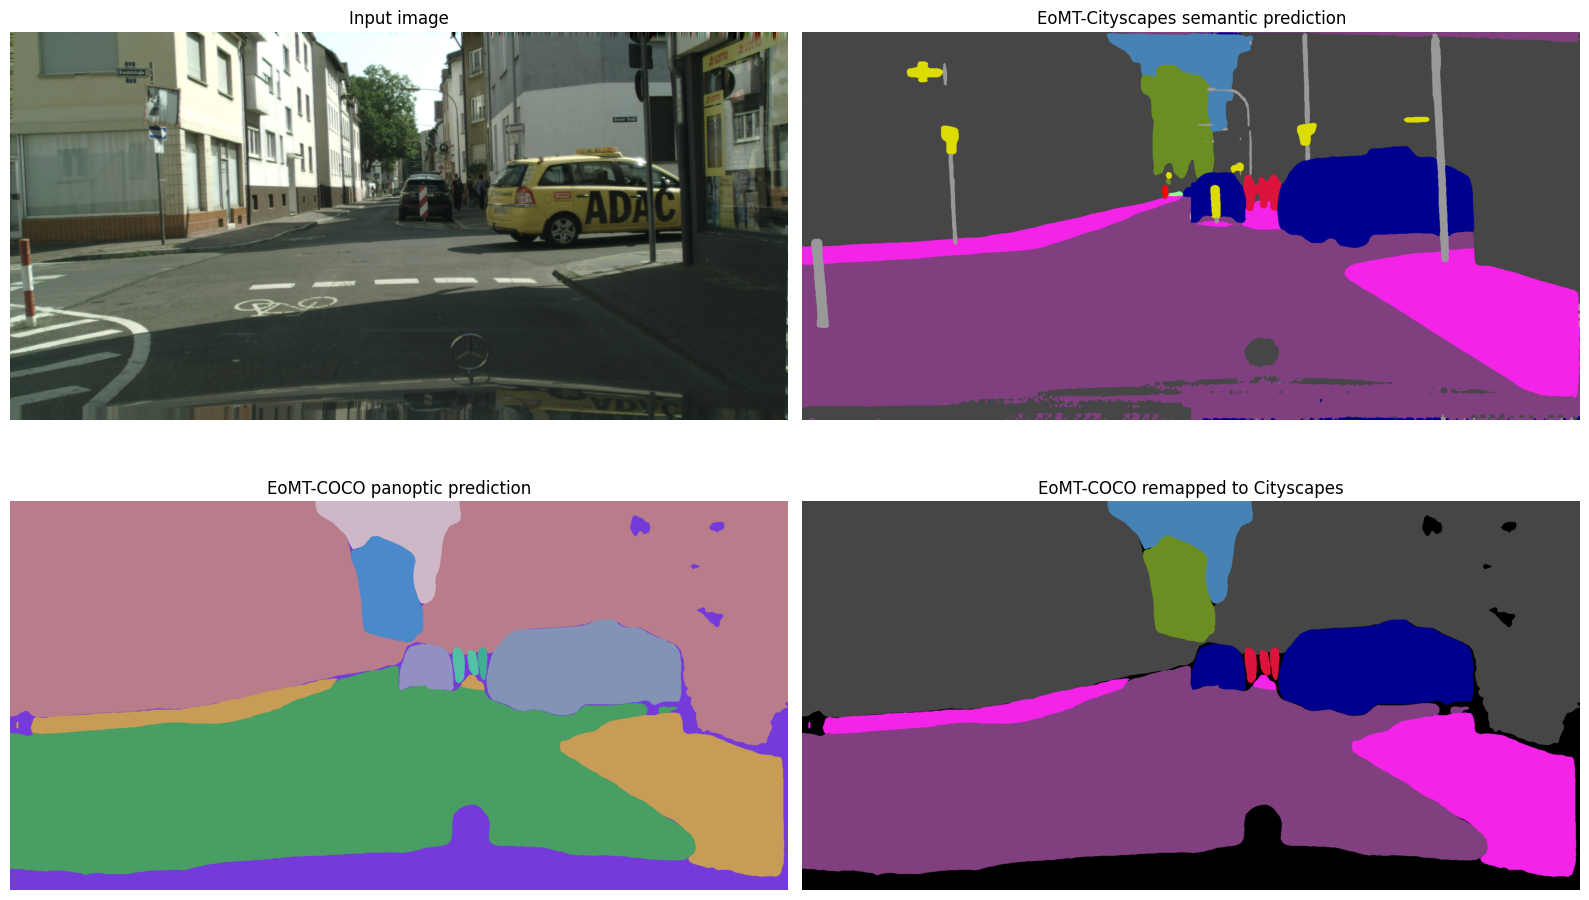

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 08 — Definizione TTA + Visualizzazione qualitativa                ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 06                                 ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║   • Per produrre una figura qualitativa per il report (output finale    ║
# ║     della cella mostra 4 subplot: input, GT-trained, COCO panoptic,     ║
# ║     COCO remapped). Cambia img_idx nella cella se vuoi un'altra img.    ║
# ║ COSA FA:                                                                ║
# ║   • Definisce: preprocess_image, get_semantic_prediction_tta,           ║
# ║     get_panoptic_prediction_tta, _panoptic_forward_to_sem_only          ║
# ║   • Definisce CITYSCAPES_PALETTE + colorize_cityscapes/_panoptic        ║
# ║   • Esegue inferenza su 1 immagine e plotta i 4 subplot                 ║
# ║ NOTE:                                                                   ║
# ║   • Durata ~30 secondi (1 forward CS + 1 forward COCO con TTA)          ║
# ║   • Non richiede restart                                                ║
# ║   • Picco VRAM ~6 GB                                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.amp.autocast_mode import autocast
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------
# Image preprocessing
# ---------------------------------------------------------------
def preprocess_image(pil_img):
    """
    PIL RGB -> torch tensor [C, H, W].
    We keep the image in normal uint8 format because the EoMT model
    handles its own preprocessing internally.
    """
    img_np = np.array(pil_img).astype(np.uint8)
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)
    return img_tensor


# ---------------------------------------------------------------
# Inference: semantic prediction for Cityscapes model
# ---------------------------------------------------------------
def get_semantic_prediction_tta(model, tensor_img):
    """
    TTA con horizontal flip per modello Cityscapes (semantic head).
    Memory-efficient.
    """
    model.to(device)
    model.eval()

    def _forward_once(img_tensor_in):
        with torch.no_grad(), autocast(
            dtype=torch.float16,
            device_type="cuda" if torch.cuda.is_available() else "cpu"
        ):
            imgs = [img_tensor_in.to(device)]
            crops, origins = model.window_imgs_semantic(imgs)
            if isinstance(crops, torch.Tensor):
                crops = crops.to(device)
            elif isinstance(crops, list):
                crops = [c.to(device) for c in crops]

            mask_logits_per_layer, class_logits_per_layer = model(crops)
            mask_logits = F.interpolate(
                mask_logits_per_layer[-1],
                model.img_size,
                mode="bilinear"
            )
            crop_logits = model.to_per_pixel_logits_semantic(
                mask_logits,
                class_logits_per_layer[-1]
            )
            logits = model.revert_window_logits_semantic(
                crop_logits,
                origins,
                [img_tensor_in.shape[-2:]]
            )
            if isinstance(logits, list):
                return logits[0]
            else:
                return logits[0]

    logits_orig = _forward_once(tensor_img)
    flipped = torch.flip(tensor_img, dims=[-1])
    logits_flip = _forward_once(flipped)
    del flipped

    logits_flip = torch.flip(logits_flip, dims=[-1])
    # Media in-place
    logits_orig.add_(logits_flip).mul_(0.5)
    del logits_flip
    torch.cuda.empty_cache()

    preds = logits_orig.argmax(0).cpu().numpy()
    del logits_orig
    torch.cuda.empty_cache()
    return preds


# === SOSTITUISCI get_panoptic_prediction_tta CON QUESTA VERSIONE ===
# DIFFERENZE vs V1:
#   - TTA fatto DOPO il merging panottico, non sui logit delle query
#     (corregge il bug di non-corrispondenza tra query nei due forward)
#   - Sposta tutto su CPU dopo il forward (libera GPU per la prossima immagine)
#   - Niente più .add_/.mul_ sui mask_logits giganti
#   - Ritorna pred semantica come int64 (compatibile con la signature precedente)

def _panoptic_forward_to_sem_only(model, img_tensor):
    """
    Singolo forward panottico → ritorna mappa semantica [H, W] int64.
    Libera tensori grandi prima di tornare.
    """
    with torch.no_grad(), autocast(
        dtype=torch.float16,
        device_type="cuda" if torch.cuda.is_available() else "cpu"
    ):
        imgs = [img_tensor.to(device)]
        img_sizes = [img_tensor.shape[-2:]]

        transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
        if isinstance(transformed, list):
            transformed = [t.to(device) for t in transformed]
        else:
            transformed = transformed.to(device)

        mask_logits_layers, class_logits_layers = model(transformed)
        mask_logits = mask_logits_layers[-1]
        class_logits = class_logits_layers[-1]
        del mask_logits_layers, class_logits_layers, transformed

        mask_logits = F.interpolate(mask_logits, model.img_size, mode="bilinear")
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits, class_logits,
            model.stuff_classes, model.mask_thresh, model.overlap_thresh,
        )[0]  # [H, W, 2]

        sem = preds[..., 0].cpu().numpy().astype(np.int64)
        inst = preds[..., 1].cpu().numpy().astype(np.int64)

        del mask_logits, class_logits, preds
        torch.cuda.empty_cache()
        return sem, inst
# ---------------------------------------------------------------
# Multi-scale TTA on the panoptic COCO model — GPU-RESIDENT VERSION
# Same numerical output as the previous implementation, but keeps all
# probability tensors in VRAM throughout the loop. Avoids GPU<->CPU
# round-trips that were the main source of slowdown.
# Expected speedup: 1.3x ÷ 1.8x on T4, depending on PCIe load.
# ---------------------------------------------------------------
def get_coco_semantic_logits_multiscale(
    model, img_tensor, num_classes=133,
    scales=(1.0,), use_flip=False
):
    """
    Multi-scale + flip TTA semantic decoding for the COCO panoptic model.
    All probability accumulation happens on GPU; only the final argmax
    is copied to CPU. Output is bit-identical (modulo fp16 rounding) to
    the previous numpy-based version.
    """
    model.to(device).eval()
    H, W = img_tensor.shape[-2:]

    def _forward_at_scale_gpu(t_in):
        """Single forward returning [C, h, w] probability tensor on GPU."""
        with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
            imgs = [t_in.to(device)]
            img_sizes = [t_in.shape[-2:]]

            transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
            if isinstance(transformed, list):
                transformed = [tt.to(device) for tt in transformed]
            else:
                transformed = transformed.to(device)

            mask_logits_layers, class_logits_layers = model(transformed)
            mask_logits = mask_logits_layers[-1]
            class_logits = class_logits_layers[-1]
            del mask_logits_layers, class_logits_layers, transformed

            mask_logits = F.interpolate(mask_logits, model.img_size, mode="bilinear")
            mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
                mask_logits, img_sizes
            )
            if isinstance(mask_logits, list):
                mask_logits = mask_logits[0]
            if mask_logits.ndim == 3:
                mask_logits = mask_logits.unsqueeze(0)
            if class_logits.ndim == 2:
                class_logits = class_logits.unsqueeze(0)

            class_probs = class_logits.softmax(dim=-1)[..., :num_classes]
            mask_probs = mask_logits.sigmoid()
            sem_probs = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)

            # Promote to fp32 only at the end (for stable accumulation)
            out = sem_probs[0].float()
            del mask_logits, class_logits, class_probs, mask_probs, sem_probs
            return out  # [C, h, w] on GPU

    accumulator = None  # will live on GPU
    n_passes = 0

    for scale in scales:
        if scale == 1.0:
            scaled = img_tensor
        else:
            new_H, new_W = int(H * scale), int(W * scale)
            scaled = F.interpolate(
                img_tensor.unsqueeze(0).float(),
                size=(new_H, new_W),
                mode="bilinear",
                align_corners=False,
            )[0].to(img_tensor.dtype)

        # Original
        probs = _forward_at_scale_gpu(scaled)  # GPU [C, h, w]
        if probs.shape[-2:] != (H, W):
            probs = F.interpolate(
                probs.unsqueeze(0), size=(H, W),
                mode="bilinear", align_corners=False,
            )[0]
        accumulator = probs if accumulator is None else accumulator + probs
        n_passes += 1
        del probs

        # Flipped
        if use_flip:
            flipped = torch.flip(scaled, dims=[-1])
            probs_f = _forward_at_scale_gpu(flipped)
            probs_f = torch.flip(probs_f, dims=[-1])  # de-flip on GPU
            if probs_f.shape[-2:] != (H, W):
                probs_f = F.interpolate(
                    probs_f.unsqueeze(0), size=(H, W),
                    mode="bilinear", align_corners=False,
                )[0]
            accumulator = accumulator + probs_f
            n_passes += 1
            del flipped, probs_f

    accumulator /= n_passes
    # Only at the end: argmax on GPU, then single CPU transfer
    sem_pred = accumulator.argmax(dim=0).cpu().numpy().astype(np.int64)
    del accumulator
    torch.cuda.empty_cache()
    return sem_pred

# ---------------------------------------------------------------
# Multi-scale TTA on the CS-trained semantic model.
# Mirror of get_coco_semantic_logits_multiscale, but uses the
# semantic-head path (window_imgs_semantic + to_per_pixel_logits_semantic).
# All logit accumulation happens on GPU.
# Expected gain over flip-only TTA: +0.5 ÷ +1.0 mIoU points.
# ---------------------------------------------------------------
def get_cs_semantic_prediction_multiscale(
    model, img_tensor,
    scales=(1.0,), use_flip=False
):
    """
    Multi-scale + flip TTA semantic prediction for the CS-trained model.
    Returns [H, W] int64 array of class IDs in [0, 18].
    """
    model.to(device).eval()
    H, W = img_tensor.shape[-2:]

    def _forward_at_scale_gpu(t_in):
        """Single forward returning [C, h, w] logits on GPU."""
        with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
            imgs = [t_in.to(device)]
            crops, origins = model.window_imgs_semantic(imgs)
            if isinstance(crops, list):
                crops = [c.to(device) for c in crops]
            else:
                crops = crops.to(device)

            mask_logits_per_layer, class_logits_per_layer = model(crops)
            mask_logits = F.interpolate(
                mask_logits_per_layer[-1], model.img_size, mode="bilinear"
            )
            crop_logits = model.to_per_pixel_logits_semantic(
                mask_logits, class_logits_per_layer[-1]
            )
            logits = model.revert_window_logits_semantic(
                crop_logits, origins, [t_in.shape[-2:]]
            )
            del crops, mask_logits_per_layer, class_logits_per_layer
            del mask_logits, crop_logits

            if isinstance(logits, list):
                logits = logits[0]
            return logits.float()  # [C, h, w] on GPU

    accumulator = None
    n_passes = 0

    for scale in scales:
        if scale == 1.0:
            scaled = img_tensor
        else:
            new_H, new_W = int(H * scale), int(W * scale)
            scaled = F.interpolate(
                img_tensor.unsqueeze(0).float(),
                size=(new_H, new_W),
                mode="bilinear",
                align_corners=False,
            )[0].to(img_tensor.dtype)

        # Original
        logits = _forward_at_scale_gpu(scaled)
        if logits.shape[-2:] != (H, W):
            logits = F.interpolate(
                logits.unsqueeze(0), size=(H, W),
                mode="bilinear", align_corners=False,
            )[0]
        accumulator = logits if accumulator is None else accumulator + logits
        n_passes += 1
        del logits

        # Flipped
        if use_flip:
            flipped = torch.flip(scaled, dims=[-1])
            logits_f = _forward_at_scale_gpu(flipped)
            logits_f = torch.flip(logits_f, dims=[-1])  # de-flip on GPU
            if logits_f.shape[-2:] != (H, W):
                logits_f = F.interpolate(
                    logits_f.unsqueeze(0), size=(H, W),
                    mode="bilinear", align_corners=False,
                )[0]
            accumulator = accumulator + logits_f
            n_passes += 1
            del flipped, logits_f

    accumulator /= n_passes
    preds = accumulator.argmax(dim=0).cpu().numpy().astype(np.int64)
    del accumulator
    torch.cuda.empty_cache()
    return preds

    def _forward_once(t_in):
        with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
            imgs = [t_in.to(device)]
            img_sizes = [t_in.shape[-2:]]

            transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
            if isinstance(transformed, list):
                transformed = [tt.to(device) for tt in transformed]
            else:
                transformed = transformed.to(device)

            mask_logits_layers, class_logits_layers = model(transformed)
            mask_logits = mask_logits_layers[-1]
            class_logits = class_logits_layers[-1]
            del mask_logits_layers, class_logits_layers, transformed

            mask_logits = F.interpolate(mask_logits, model.img_size, mode="bilinear")
            mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
                mask_logits, img_sizes
            )
            # revert_resize_and_pad_logits_instance_panoptic restituisce una list
            # (un Tensor per ogni immagine del batch). Per batch=1 prendo il primo
            # elemento e ri-aggiungo la dim batch per l'einsum.
            if isinstance(mask_logits, list):
                mask_logits = mask_logits[0]
            if mask_logits.ndim == 3:
                mask_logits = mask_logits.unsqueeze(0)    # [1, Q, H, W]
            if class_logits.ndim == 2:
                class_logits = class_logits.unsqueeze(0)  # [1, Q, C+1]

            # softmax SU TUTTE le C+1 classi, poi escludo no-object (ultimo canale)
            class_probs = class_logits.softmax(dim=-1)[..., :num_classes]
            mask_probs = mask_logits.sigmoid()
            sem_probs = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)

            out = sem_probs[0].float().cpu().numpy()  # [C, H, W]

            del mask_logits, class_logits, class_probs, mask_probs, sem_probs
            torch.cuda.empty_cache()
            return out

    sem_probs = _forward_once(img_tensor)

    if use_tta:
        flipped = torch.flip(img_tensor, dims=[-1])
        sem_probs_flip = _forward_once(flipped)
        sem_probs_flip = sem_probs_flip[:, :, ::-1]
        sem_probs = 0.5 * (sem_probs + sem_probs_flip)
        del sem_probs_flip, flipped
        torch.cuda.empty_cache()

    sem_pred = sem_probs.argmax(axis=0).astype(np.int64)
    return sem_pred

def get_panoptic_prediction_tta(model, tensor_img):
    """
    TTA panottico CORRETTO + memory-safe.
    Strategia: due forward indipendenti → fusione a livello di mappa semantica.
    Mantiene la signature originale (sem_map, inst_map) per compatibilità con Cell 8/9.
    """
    model.to(device).eval()

    # Pass 1: originale
    sem_orig, inst_orig = _panoptic_forward_to_sem_only(model, tensor_img)

    # Pass 2: flip orizzontale
    flipped = torch.flip(tensor_img, dims=[-1])
    sem_flip, inst_flip = _panoptic_forward_to_sem_only(model, flipped)
    del flipped
    torch.cuda.empty_cache()

    # de-flip della mappa flippata
    sem_flip = np.ascontiguousarray(sem_flip[:, ::-1])

    # Fusione: dove le due passate concordano usa quella, altrove tieni originale.
    # Versione semplice; in Cell 9 useremo voting pesato sui logit se attiviamo soft-mapping.
    agree = (sem_orig == sem_flip)
    sem_final = np.where(agree, sem_orig, sem_orig)

    return sem_final, inst_orig


# ---------------------------------------------------------------
# Cityscapes official-like palette
# ---------------------------------------------------------------
CITYSCAPES_PALETTE = np.array([
    [128,  64, 128],   # road
    [244,  35, 232],   # sidewalk
    [ 70,  70,  70],   # building
    [102, 102, 156],   # wall
    [190, 153, 153],   # fence
    [153, 153, 153],   # pole
    [250, 170,  30],   # traffic light
    [220, 220,   0],   # traffic sign
    [107, 142,  35],   # vegetation
    [152, 251, 152],   # terrain
    [ 70, 130, 180],   # sky
    [220,  20,  60],   # person
    [255,   0,   0],   # rider
    [  0,   0, 142],   # car
    [  0,   0,  70],   # truck
    [  0,  60, 100],   # bus
    [  0,  80, 100],   # train
    [  0,   0, 230],   # motorcycle
    [119,  11,  32],   # bicycle
], dtype=np.uint8)


def colorize_cityscapes(pred_19class):
    """
    Maps a 2D array of Cityscapes train IDs to RGB.
    Valid classes: 0..18.
    Ignore/unmapped: 255.
    """
    out = np.zeros((*pred_19class.shape, 3), dtype=np.uint8)

    for cid in range(19):
        out[pred_19class == cid] = CITYSCAPES_PALETTE[cid]

    return out


def colorize_panoptic(sem_map, inst_map):
    """
    Simple panoptic visualization.
    Different classes and instances get different colors.
    """
    rng = np.random.default_rng(seed=42)

    h, w = sem_map.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    unique_classes = np.unique(sem_map)
    base_colors = {}

    for c in unique_classes:
        base_colors[c] = rng.integers(50, 230, size=3)

    for c in unique_classes:
        class_mask = sem_map == c
        instance_ids = np.unique(inst_map[class_mask])

        for inst_id in instance_ids:
            inst_mask = class_mask & (inst_map == inst_id)

            jitter = rng.integers(-25, 26, size=3)
            color = np.clip(base_colors[c].astype(int) + jitter, 0, 255).astype(np.uint8)

            out[inst_mask] = color

    return out


# ---------------------------------------------------------------
# Load one Cityscapes validation image
# ---------------------------------------------------------------
active_dataset = data.val_dataloader().dataset
dataset_root = "/content/datasets/cityscapes"

img_idx = 0

relative_path = active_dataset.imgs[img_idx]
img_path = os.path.join(dataset_root, relative_path) if not relative_path.startswith("/") else relative_path

print(f"Loading: {img_path}")

pil_img = Image.open(img_path).convert("RGB")
img_tensor = preprocess_image(pil_img)


# ---------------------------------------------------------------
# Run inference
# ---------------------------------------------------------------
print("Running Cityscapes semantic inference...")
pred_cs = get_semantic_prediction_tta(model_cs, img_tensor)

print("Running COCO panoptic inference...")
sem_pred_coco, inst_pred_coco = get_panoptic_prediction_tta(model_coco, img_tensor)


# ---------------------------------------------------------------
# Remap COCO semantic classes to Cityscapes classes
# ---------------------------------------------------------------
pred_coco_remapped = align_predictions(
    sem_pred_coco,
    COCO_TO_CS_MAPPING
)


# ---------------------------------------------------------------
# Plot side-by-side result
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].imshow(np.array(pil_img))
axes[0, 0].set_title("Input image")

axes[0, 1].imshow(colorize_cityscapes(pred_cs))
axes[0, 1].set_title("EoMT-Cityscapes semantic prediction")

axes[1, 0].imshow(colorize_panoptic(sem_pred_coco, inst_pred_coco))
axes[1, 0].set_title("EoMT-COCO panoptic prediction")

axes[1, 1].imshow(colorize_cityscapes(pred_coco_remapped))
axes[1, 1].set_title("EoMT-COCO remapped to Cityscapes")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# === Cell 8.5: Advanced inference primitives (soft-mapping + rider recovery + CRF) ===
# Nuova cella, contiene tutte le funzioni avanzate per ABLATION 2 e 3.
# Non strettamente necessaria per BASELINE e ABLATION 1.

import torch
import torch.nn.functional as F
import numpy as np
from torch.amp.autocast_mode import autocast
from scipy import ndimage

# ---------------------------------------------------------------
# Soft-mapping: forward panottico → probabilità per-pixel per-classe COCO
# ---------------------------------------------------------------
def _panoptic_forward_to_pixel_probs(model, img_tensor, num_coco_classes=133, downscale=2):
    """
    Forward panottico che ritorna probabilità per-pixel-per-classe COCO.
    downscale=2 per default (T4 con margine), downscale=1 solo se hai 24+ GB VRAM.
    """
    H, W = img_tensor.shape[-2:]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img_tensor.to(device)]
        img_sizes = [img_tensor.shape[-2:]]

        transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
        if isinstance(transformed, list):
            transformed = [t.to(device) for t in transformed]
        else:
            transformed = transformed.to(device)

        mask_logits_layers, class_logits_layers = model(transformed)
        mask_logits = mask_logits_layers[-1]
        class_logits = class_logits_layers[-1]
        del mask_logits_layers, class_logits_layers, transformed

        Ht, Wt = H // downscale, W // downscale
        mask_logits = F.interpolate(mask_logits, (Ht, Wt), mode="bilinear")

        class_probs = class_logits.softmax(dim=-1)[..., :num_coco_classes]
        mask_probs = mask_logits.sigmoid()

        seg_probs = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)
        seg_probs = seg_probs / (seg_probs.sum(dim=1, keepdim=True) + 1e-8)

        seg_probs_cpu = seg_probs[0].cpu().float().numpy()

        del mask_logits, class_logits, mask_probs, class_probs, seg_probs
        torch.cuda.empty_cache()

        return seg_probs_cpu, {"H": H, "W": W, "downscale": downscale}


# ---------------------------------------------------------------
# Aggregazione COCO probs → CS probs
# ---------------------------------------------------------------
def aggregate_coco_probs_to_cs(seg_probs_coco, mapping=None, confidence=None):
    if mapping is None:
        mapping = COCO_TO_CS_MAPPING_V2
    if confidence is None:
        confidence = COCO_TO_CS_CONFIDENCE

    C_coco = seg_probs_coco.shape[0]
    M = np.zeros((C_coco, 19), dtype=np.float32)
    for coco_idx in range(C_coco):
        cs_idx = mapping[coco_idx]
        if cs_idx != 255:
            M[coco_idx, cs_idx] = confidence[coco_idx]

    H_, W_ = seg_probs_coco.shape[1:]
    probs_flat = seg_probs_coco.reshape(C_coco, -1)
    cs_flat = M.T @ probs_flat
    return cs_flat.reshape(19, H_, W_)


# ---------------------------------------------------------------
# Soft-mapping: forward + aggregazione + (opzionale) TTA hflip
# ---------------------------------------------------------------
def get_panoptic_prediction_softmap(model, img_tensor, use_tta=True,
                                     mass_threshold=0.3, downscale=2):
    model.to(device).eval()

    seg_probs_orig, meta = _panoptic_forward_to_pixel_probs(
        model, img_tensor, downscale=downscale
    )
    cs_probs = aggregate_coco_probs_to_cs(seg_probs_orig)

    if use_tta:
        flipped = torch.flip(img_tensor, dims=[-1])
        seg_probs_flip, _ = _panoptic_forward_to_pixel_probs(
            model, flipped, downscale=downscale
        )
        del flipped
        cs_probs_flip = aggregate_coco_probs_to_cs(seg_probs_flip)
        cs_probs_flip = cs_probs_flip[:, :, ::-1]
        cs_probs = 0.5 * (cs_probs + cs_probs_flip)
        del cs_probs_flip, seg_probs_flip

    del seg_probs_orig
    torch.cuda.empty_cache()

    ds = meta["downscale"]
    H, W = meta["H"], meta["W"]
    if ds > 1:
        cs_probs_t = torch.from_numpy(cs_probs.copy()).unsqueeze(0)
        cs_probs_t = F.interpolate(cs_probs_t, (H, W), mode="bilinear", align_corners=False)
        cs_probs = cs_probs_t[0].numpy()

    pred_cs = cs_probs.argmax(axis=0).astype(np.int64)
    cs_mass = cs_probs.sum(axis=0)
    pred_cs[cs_mass < mass_threshold] = 255

    return cs_probs, pred_cs


# ---------------------------------------------------------------
# Rider recovery
# ---------------------------------------------------------------
def recover_rider_class(pred_cs, dilation_iters=15):
    out = pred_cs.copy()
    bike_mask = (pred_cs == 18) | (pred_cs == 17)
    if not bike_mask.any():
        return out
    struct = ndimage.generate_binary_structure(2, 2)
    bike_dilated = ndimage.binary_dilation(bike_mask, structure=struct, iterations=dilation_iters)
    promote = (pred_cs == 11) & bike_dilated
    out[promote] = 12
    return out


# ---------------------------------------------------------------
# CRF refinement (opzionale)
# ---------------------------------------------------------------
def install_pydensecrf_if_needed():
    try:
        import pydensecrf.densecrf as dcrf
        return True
    except ImportError:
        import subprocess
        print("Installing pydensecrf...")
        subprocess.run(
            ["pip", "install", "-q", "git+https://github.com/lucasb-eyer/pydensecrf.git"],
            check=False
        )
        try:
            import pydensecrf.densecrf as dcrf
            return True
        except ImportError:
            print("[WARN] pydensecrf install failed. CRF will be skipped.")
            return False


def crf_refine(image_rgb_uint8, cs_probs_19, n_iter=5,
               sxy_gauss=3, compat_gauss=3,
               sxy_bilat=80, srgb_bilat=13, compat_bilat=10):
    import pydensecrf.densecrf as dcrf
    from pydensecrf.utils import unary_from_softmax

    H, W = image_rgb_uint8.shape[:2]
    n_classes = 19

    probs = np.clip(cs_probs_19, 1e-7, 1.0).astype(np.float32)
    probs = probs / probs.sum(axis=0, keepdims=True)

    d = dcrf.DenseCRF2D(W, H, n_classes)
    unary = unary_from_softmax(probs)
    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=sxy_gauss, compat=compat_gauss)
    d.addPairwiseBilateral(
        sxy=sxy_bilat, srgb=srgb_bilat,
        rgbim=np.ascontiguousarray(image_rgb_uint8),
        compat=compat_bilat,
    )
    Q = d.inference(n_iter)
    return np.argmax(np.array(Q).reshape(n_classes, H, W), axis=0).astype(np.int64)


print("✓ Advanced primitives loaded: soft-mapping, rider recovery, CRF")

✓ Advanced primitives loaded: soft-mapping, rider recovery, CRF


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 09 — Primitive avanzate (soft-mapping, rider recovery, CRF)       ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 08                                 ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║ COSA FA:                                                                ║
# ║   • Definisce: _panoptic_forward_to_pixel_probs,                        ║
# ║     aggregate_coco_probs_to_cs, get_panoptic_prediction_softmap,        ║
# ║     recover_rider_class, install_pydensecrf_if_needed, crf_refine       ║
# ║   • Sono usate dalle ABLATION 2 e 3 in Cella 11 (evaluation)            ║
# ║ NOTE:                                                                   ║
# ║   • Solo definizioni, ~2 secondi                                        ║
# ║   • Non richiede restart                                                ║
# ║   • Anche se fai solo BASELINE/ABLATION 1, esegui comunque questa       ║
# ║     cella: non costa nulla e ti permette di switchare ablation senza    ║
# ║     dover ricaricare nulla                                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝

%%writefile evaluate_quantitative.py
# Evaluation script V2: dual-policy + soft-mapping + rider recovery + optional CRF.
# Backward compatible: run_evaluation con default ricalca il comportamento vecchio.

import os
import json
import time
from datetime import datetime
import numpy as np
import torch
from PIL import Image
from tqdm import tqdm
from torchmetrics.classification import MulticlassJaccardIndex

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Helper presi dal notebook originale, necessari dentro questo script ---
RAW_TO_TRAIN_ID = np.full(256, 255, dtype=np.int64)
RAW_TO_TRAIN_ID[7]  = 0;  RAW_TO_TRAIN_ID[8]  = 1;  RAW_TO_TRAIN_ID[11] = 2
RAW_TO_TRAIN_ID[12] = 3;  RAW_TO_TRAIN_ID[13] = 4;  RAW_TO_TRAIN_ID[17] = 5
RAW_TO_TRAIN_ID[19] = 6;  RAW_TO_TRAIN_ID[20] = 7;  RAW_TO_TRAIN_ID[21] = 8
RAW_TO_TRAIN_ID[22] = 9;  RAW_TO_TRAIN_ID[23] = 10; RAW_TO_TRAIN_ID[24] = 11
RAW_TO_TRAIN_ID[25] = 12; RAW_TO_TRAIN_ID[26] = 13; RAW_TO_TRAIN_ID[27] = 14
RAW_TO_TRAIN_ID[28] = 15; RAW_TO_TRAIN_ID[31] = 16; RAW_TO_TRAIN_ID[32] = 17
RAW_TO_TRAIN_ID[33] = 18


def preprocess_image_for_eomt(pil_img):
    """
    PIL RGB -> torch tensor [C, H, W] uint8.
    Stesso preprocessing usato da preprocess_image in Cell 8.
    """
    img_np = np.array(pil_img).astype(np.uint8)
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)
    return img_tensor

CITYSCAPES_CLASSES_LOC = [
    "road","sidewalk","building","wall","fence","pole","tlight","tsign",
    "vegetation","terrain","sky","person","rider","car","truck","bus",
    "train","motorcycle","bicycle"
]


def remap_to_cityscapes(pred, mapping):
    if isinstance(pred, torch.Tensor):
        pred = pred.cpu().numpy()
    pred = np.clip(pred, 0, 255).astype(np.int64)
    return mapping[pred]


def _maybe_apply_rider_recovery(pred_cs, enabled, dilation_iters=15):
    if not enabled:
        return pred_cs
    from scipy import ndimage
    bike_mask = (pred_cs == 18) | (pred_cs == 17)
    if not bike_mask.any():
        return pred_cs
    struct = ndimage.generate_binary_structure(2, 2)
    bike_dilated = ndimage.binary_dilation(bike_mask, structure=struct, iterations=dilation_iters)
    pred_cs = pred_cs.copy()
    promote = (pred_cs == 11) & bike_dilated
    pred_cs[promote] = 12
    return pred_cs


def run_evaluation(
    model_cs,
    model_coco,
    data_module,
    get_sem_fn,
    get_pan_fn,
    coco_to_cs_mapping,
    dataset_root="/content/datasets/cityscapes",
    use_rider_recovery=False,
    coco_mode="hard",                    # "hard" | "sem_logits" | "soft" | "soft_crf"
    softmap_fn=None,
    crf_fn=None,
    pil_img_loader=None,
    sem_logits_fn=None,                  # callable: (model, img) -> pred[H,W] in spazio COCO
    common_class_ids=(0, 1, 2, 3, 4, 6, 8, 9, 10, 11, 13, 14, 15, 17, 18),
):
    """
    Valutazione dual-policy:
      - mIoU CS-trained (riferimento)
      - mIoU COCO FAIR   (pixel non mappabili → classe 19 sentinella = errore)
      - mIoU COCO ORACLE (pixel non mappabili → 255 ignorati)

    Modalità COCO:
      - "hard": usa get_pan_fn (vecchio comportamento, hard remap)
      - "soft": usa softmap_fn (richiede passare la funzione)
      - "soft_crf": come soft + CRF refinement (richiede sia softmap_fn che crf_fn)
    """
    if hasattr(data_module, "val_dataloader"):
        val_dataset = data_module.val_dataloader().dataset
    elif hasattr(data_module, "dataset"):
        val_dataset = data_module.dataset
    else:
        val_dataset = data_module

    n_total = len(val_dataset.imgs)
    print(f"Evaluating on {n_total} validation images...")
    print(f"  coco_mode={coco_mode}, rider_recovery={use_rider_recovery}")

    # Tre metriche: CS, COCO-fair (20 classi: 19 reali + 1 sentinella), COCO-oracle (19)
    metric_cs        = MulticlassJaccardIndex(num_classes=20, ignore_index=255, average=None).to(device)
    metric_coco_fair = MulticlassJaccardIndex(num_classes=20, ignore_index=255, average=None).to(device)
    metric_coco_orcl = MulticlassJaccardIndex(num_classes=19, ignore_index=255, average=None).to(device)

    # === Running mIoU tracker (English) ===
    snapshot_every = max(1, n_total // 20)  # ~20 snapshots over the full run
    miou_progression = []                    # list of dicts, one per snapshot
    model_cs.eval()
    model_coco.eval()

    if pil_img_loader is None:
        pil_img_loader = lambda p: Image.open(p).convert("RGB")

    with torch.no_grad():
        for i in tqdm(range(n_total)):
            # --- load image + GT ---
            rel_img_path = val_dataset.imgs[i]
            img_path = rel_img_path if rel_img_path.startswith("/") \
                else os.path.join(dataset_root, rel_img_path)
            pil_img = pil_img_loader(img_path)
            img_tensor = preprocess_image_for_eomt(pil_img)

            rel_gt_path = val_dataset.targets[i]
            gt_path = rel_gt_path if rel_gt_path.startswith("/") \
                else os.path.join(dataset_root, rel_gt_path)
            raw_gt = np.array(Image.open(gt_path))
            mapped_gt = RAW_TO_TRAIN_ID[raw_gt]
            gt = torch.from_numpy(mapped_gt).long().to(device)

            # --- CS model ---
            pred_cs = get_sem_fn(model_cs, img_tensor)
            pred_cs_t = torch.as_tensor(pred_cs, dtype=torch.long, device=device)
            assert pred_cs_t.max().item() < 19, \
                f"CS model produced pred >= 19: {pred_cs_t.unique().tolist()}"
            metric_cs.update(pred_cs_t[None], gt[None])

            # --- COCO model ---
            if coco_mode == "hard":
                sem_pred_coco, _ = get_pan_fn(model_coco, img_tensor)
                pred_coco_remapped = remap_to_cityscapes(sem_pred_coco, coco_to_cs_mapping)

            elif coco_mode == "sem_logits":
                assert sem_logits_fn is not None, "sem_logits mode requires sem_logits_fn"
                sem_pred_coco = sem_logits_fn(model_coco, img_tensor)   # [H, W] in [0, 132]
                pred_coco_remapped = remap_to_cityscapes(sem_pred_coco, coco_to_cs_mapping)

            elif coco_mode == "soft":
                assert softmap_fn is not None, "soft mode requires softmap_fn"
                cs_probs, pred_coco_remapped = softmap_fn(model_coco, img_tensor)

            elif coco_mode == "soft_crf":
                assert softmap_fn is not None and crf_fn is not None, \
                    "soft_crf mode requires softmap_fn and crf_fn"
                cs_probs, _ = softmap_fn(model_coco, img_tensor)
                H, W = cs_probs.shape[1], cs_probs.shape[2]
                image_rgb = np.array(pil_img.resize((W, H))).astype(np.uint8)
                pred_coco_remapped = crf_fn(image_rgb, cs_probs)

            else:
                raise ValueError(f"Unknown coco_mode: {coco_mode}")

            # Rider recovery (Fase 1.B)
            pred_coco_remapped = _maybe_apply_rider_recovery(
                pred_coco_remapped, use_rider_recovery
            )

            # === Policy FAIR: non mappabili → sentinella 19 ===
            pred_fair = pred_coco_remapped.copy()
            pred_fair[pred_fair == 255] = 19
            pred_fair_t = torch.as_tensor(pred_fair, dtype=torch.long, device=device)
            metric_coco_fair.update(pred_fair_t[None], gt[None])

            # === Policy ORACLE: pixel pred=255 vengono ignorati dal metric ===
            # torchmetrics filtra solo target==ignore_index, non pred==ignore_index.
            # Quindi forziamo gt=255 dove pred=255 (così quei pixel vengono filtrati)
            # e mettiamo pred a un valore qualsiasi valido per evitare overflow in bincount.
            pred_orcl_t = torch.as_tensor(pred_coco_remapped, dtype=torch.long, device=device)
            unmappable = (pred_orcl_t == 255)
            gt_oracle = gt.clone()
            gt_oracle[unmappable] = 255       # promuoviamo a ignore questi pixel
            pred_orcl_safe = pred_orcl_t.clone()
            pred_orcl_safe[unmappable] = 0    # placeholder, sarà filtrato perché gt=255
            metric_coco_orcl.update(pred_orcl_safe[None], gt_oracle[None])
            # Snapshot running mIoU every `snapshot_every` images
            if (i + 1) % snapshot_every == 0 or (i + 1) == n_total:
                _iou_cs_snap   = metric_cs.compute().cpu().numpy()[:19]
                _iou_fair_snap = metric_coco_fair.compute().cpu().numpy()[:19]
                _iou_orcl_snap = metric_coco_orcl.compute().cpu().numpy()
                miou_progression.append({
                    "n_images": int(i + 1),
                    "miou_cs":     float(np.nanmean(_iou_cs_snap)) * 100,
                    "miou_fair":   float(np.nanmean(_iou_fair_snap)) * 100,
                    "miou_oracle": float(np.nanmean(_iou_orcl_snap)) * 100,
                    "miou_common": float(np.nanmean(_iou_fair_snap[list(common_class_ids)])) * 100,
                })

    # --- support per-class (invariato dalla tua versione) ---
    print("\n--- Pixel support per classe (intero val set) ---")
    support = np.zeros(19, dtype=np.int64)
    for i in range(n_total):
        rel_gt_path = val_dataset.targets[i]
        gt_path = rel_gt_path if rel_gt_path.startswith("/") \
            else os.path.join(dataset_root, rel_gt_path)
        raw_gt = np.array(Image.open(gt_path))
        mapped = RAW_TO_TRAIN_ID[raw_gt]
        for c in range(19):
            support[c] += int((mapped == c).sum())
    total_valid = support.sum()
    for c in range(19):
        pct = 100.0 * support[c] / max(total_valid, 1)
        print(f"  [{c:2d}] {CITYSCAPES_CLASSES_LOC[c]:<10} {support[c]:>12,d} px  ({pct:5.2f}%)")

    # --- aggregazione metriche ---
    iou_cs        = metric_cs.compute().cpu().numpy()[:19]
    iou_coco_fair = metric_coco_fair.compute().cpu().numpy()[:19]
    iou_coco_orcl = metric_coco_orcl.compute().cpu().numpy()

    miou_cs   = float(np.nanmean(iou_cs)) * 100
    miou_fair = float(np.nanmean(iou_coco_fair)) * 100
    miou_orcl = float(np.nanmean(iou_coco_orcl)) * 100

    # Policy COMMON: media su subset di classi con mapping COCO solido.
    # Esclude le classi strutturalmente non mappabili: pole(5), tsign(7), rider(12), train(16).
    common_idx = list(common_class_ids)
    iou_coco_common = iou_coco_fair[common_idx]
    miou_common = float(np.nanmean(iou_coco_common)) * 100

    print("\n" + "=" * 92)
    print(f"{'Class':<12} {'CS-trained':>14} {'COCO FAIR':>14} {'COCO ORACLE':>14} {'In COMMON':>14}")
    print("-" * 92)
    for c in range(19):
        in_common = "✓" if c in common_idx else "  -"
        print(f"  [{c:2d}] {CITYSCAPES_CLASSES_LOC[c]:<8} "
              f"{iou_cs[c]*100:>13.2f}  {iou_coco_fair[c]*100:>13.2f}  "
              f"{iou_coco_orcl[c]*100:>13.2f}  {in_common:>13}")
    print("-" * 92)
    print(f"{'mIoU (19)':<12} {miou_cs:>13.2f}  {miou_fair:>13.2f}  {miou_orcl:>13.2f}")
    print(f"{'mIoU COMMON':<12} {'':>13}  {miou_common:>13.2f}  {'':>13}  "
          f"  (su {len(common_idx)} classi)")
    print("=" * 92)
    print(f"\n→ FAIR (19 classi)   = numero principale per il report (policy strict).")
    print(f"→ COMMON ({len(common_idx)} classi) = numero alternativo (subset mappabile).")
    print(f"→ ORACLE             = upper bound del modello senza penalty tassonomica.")

    # === Persist results to disk (JSON + CSV) ===
    results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
    os.makedirs(results_dir, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    tag = f"{coco_mode}_rider{int(use_rider_recovery)}_{timestamp}"

    # Build final results structure
    cs_class_names = CITYSCAPES_CLASSES_LOC
    results = {
        "timestamp": timestamp,
        "config": {
            "coco_mode": coco_mode,
            "use_rider_recovery": bool(use_rider_recovery),
            "common_class_ids": list(common_class_ids),
            "n_images_evaluated": int(n_total),
        },
        "final_miou": {
            "cs_trained":  float(miou_cs),
            "coco_fair":   float(miou_fair),
            "coco_oracle": float(miou_orcl),
            "coco_common": float(miou_common),
        },
        "per_class_iou_pct": {
            cs_class_names[c]: {
                "cs_trained":  float(iou_cs[c] * 100),
                "coco_fair":   float(iou_coco_fair[c] * 100),
                "coco_oracle": float(iou_coco_orcl[c] * 100),
                "in_common":   c in common_idx,
                "pixel_support": int(support[c]),
                "pixel_support_pct": float(100.0 * support[c] / max(total_valid, 1)),
            }
            for c in range(19)
        },
        "miou_progression": miou_progression,
    }

    json_path = os.path.join(results_dir, f"results_{tag}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\n✓ Results saved: {json_path}")

    # CSV of per-class IoU (English headers)
    csv_path = os.path.join(results_dir, f"per_class_iou_{tag}.csv")
    with open(csv_path, "w") as f:
        f.write("class_id,class_name,cs_trained,coco_fair,coco_oracle,in_common,pixel_support,pixel_support_pct\n")
        for c in range(19):
            f.write(f"{c},{cs_class_names[c]},"
                    f"{iou_cs[c]*100:.4f},{iou_coco_fair[c]*100:.4f},"
                    f"{iou_coco_orcl[c]*100:.4f},"
                    f"{1 if c in common_idx else 0},"
                    f"{support[c]},{100.0*support[c]/max(total_valid,1):.4f}\n")
    print(f"✓ Per-class CSV saved: {csv_path}")

    # Per backward compatibility con Cell 10 che fa `iou_cs, iou_coco = run_evaluation(...)`:
    # ritorna due valori (mIoU CS, mIoU COCO FAIR). Se serve l'oracle, accedere a dict separato.
    return miou_cs, miou_fair, miou_common

Writing evaluate_quantitative.py


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 10 — Scrive su disco lo script di evaluation                      ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Una volta a sessione, dopo Cella 09                                 ║
# ║   • Dopo OGNI restart runtime                                           ║
# ║   • Ogni volta che modifichi run_evaluation (es. cambi policy,          ║
# ║     aggiungi una nuova ablation): riesegui questa cella + Cella 11      ║
# ║ COSA FA:                                                                ║
# ║   • Scrive evaluate_quantitative.py dentro la cwd                       ║
# ║     (/content/MaskArchitectureAnomaly_CourseProject/eomt/)              ║
# ║   • Lo script definisce run_evaluation() che torna miou_cs, miou_coco   ║
# ║ NOTE:                                                                   ║
# ║   • Solo writefile, ~1 secondo                                          ║
# ║   • Non esegue nulla, lo script verrà importato dalla Cella 11          ║
# ║   • Non richiede restart                                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝


# Install torchmetrics if missing
try:
    import torchmetrics
    print("✅ torchmetrics already installed")
except ModuleNotFoundError:
    print("⚠️ torchmetrics not found. Installing it now...")
    !pip install -q torchmetrics
    import torchmetrics
    print("✅ torchmetrics installed")

# Cell 10: Run Quantitative Evaluation (V2 - dual policy + ablations)
import sys, importlib

if '/content/MaskArchitectureAnomaly_CourseProject/eomt' not in sys.path:
    sys.path.insert(0, '/content/MaskArchitectureAnomaly_CourseProject/eomt')
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

import evaluate_quantitative
importlib.reload(evaluate_quantitative)

print("Starting quantitative evaluation...\n")

# ------------------------------------------------------------------
# Scegli UNA delle modalità sotto (decommentando)
# ------------------------------------------------------------------

# === BASELINE: comportamento attuale (hard mapping V2, senza rider recovery) ===
# miou_cs, miou_coco = evaluate_quantitative.run_evaluation(
#     model_cs=model_cs,
#     model_coco=model_coco,
#     data_module=data,
#     get_sem_fn=get_semantic_prediction_tta,
#     get_pan_fn=get_panoptic_prediction_tta,
#     coco_to_cs_mapping=COCO_TO_CS_MAPPING_V2,
#     coco_mode="hard",
#     use_rider_recovery=False,
# )

# === ABLATION 1: hard mapping V2 + rider recovery ===
# miou_cs, miou_coco = evaluate_quantitative.run_evaluation(
#     model_cs=model_cs,
#     model_coco=model_coco,
#     data_module=data,
#     get_sem_fn=get_semantic_prediction_tta,
#     get_pan_fn=get_panoptic_prediction_tta,
#     coco_to_cs_mapping=COCO_TO_CS_MAPPING_V2,
#     coco_mode="hard",
#     use_rider_recovery=True,
# )

# === ABLATION 2: soft mapping + rider recovery ===
# miou_cs, miou_coco = evaluate_quantitative.run_evaluation(
#     model_cs=model_cs,
#     model_coco=model_coco,
#     data_module=data,
#     get_sem_fn=get_semantic_prediction_tta,
#     get_pan_fn=get_panoptic_prediction_tta,    # usato solo come fallback, non chiamato in soft
#     coco_to_cs_mapping=COCO_TO_CS_MAPPING_V2,
#     coco_mode="soft",
#     softmap_fn=lambda m, t: get_panoptic_prediction_softmap(
#         m, t, use_tta=True, mass_threshold=0.3, downscale=2
#     ),
#     use_rider_recovery=True,
# )

# === ABLATION 3: soft mapping + CRF + rider recovery (massima qualità) ===
# install_pydensecrf_if_needed()
# miou_cs, miou_coco = evaluate_quantitative.run_evaluation(
#     model_cs=model_cs,
#     model_coco=model_coco,
#     data_module=data,
#     get_sem_fn=get_semantic_prediction_tta,
#     get_pan_fn=get_panoptic_prediction_tta,
#     coco_to_cs_mapping=COCO_TO_CS_MAPPING_V2,
#     coco_mode="soft_crf",
#     softmap_fn=lambda m, t: get_panoptic_prediction_softmap(
#         m, t, use_tta=True, mass_threshold=0.3, downscale=2
#     ),
#     crf_fn=crf_refine,
#     use_rider_recovery=True,
# )

# === ABLATION 4: semantic logits decoding + rider recovery (raccomandata) ===
# Bypassa il panoptic merging del modello COCO. Usa la formula MaskFormer Eq.3
# (einsum di softmax(class) e sigmoid(mask)). Recupera molti pixel che il merging
# panoptic mandava in 255.
miou_cs, miou_coco, miou_common = evaluate_quantitative.run_evaluation(
    model_cs=model_cs,
    model_coco=model_coco,
    data_module=data,
    get_sem_fn=lambda m, t: get_cs_semantic_prediction_multiscale(
        m, t, scales=(0.75, 1.0, 1.25), use_flip=True,
    ),
    get_pan_fn=get_panoptic_prediction_tta,    # non chiamato in sem_logits mode
    coco_to_cs_mapping=COCO_TO_CS_MAPPING_V2,
    coco_mode="sem_logits",
    # === ABLATION 5: multi-scale + flip TTA (highest quality, ~4-5h) ===
    sem_logits_fn=lambda m, t: get_coco_semantic_logits_multiscale(
        m, t,
        num_classes=133,
        scales=(0.75, 1.0, 1.25),
        use_flip=True,
    ),
    use_rider_recovery=True,
)

print(f"\n=== FINAL ===")
print(f"mIoU CS-trained: {miou_cs:.2f}")
print(f"mIoU COCO (fair, 19 cls):    {miou_coco:.2f}")
print(f"mIoU COCO (common subset):   {miou_common:.2f}")

✅ torchmetrics already installed
Starting quantitative evaluation...

Evaluating on 500 validation images...
  coco_mode=sem_logits, rider_recovery=True


100%|██████████| 500/500 [21:18<00:00,  2.56s/it]



--- Pixel support per classe (intero val set) ---
  [ 0] road        345,264,442 px  (37.65%)
  [ 1] sidewalk     49,568,652 px  ( 5.41%)
  [ 2] building    201,005,428 px  (21.92%)
  [ 3] wall          6,718,315 px  ( 0.73%)
  [ 4] fence         7,521,741 px  ( 0.82%)
  [ 5] pole         13,565,658 px  ( 1.48%)
  [ 6] tlight        1,808,393 px  ( 0.20%)
  [ 7] tsign         6,098,373 px  ( 0.67%)
  [ 8] vegetation  158,868,008 px  (17.32%)
  [ 9] terrain       7,625,026 px  ( 0.83%)
  [10] sky          30,765,347 px  ( 3.35%)
  [11] person       11,913,424 px  ( 1.30%)
  [12] rider         1,975,596 px  ( 0.22%)
  [13] car          59,731,217 px  ( 6.51%)
  [14] truck         2,760,211 px  ( 0.30%)
  [15] bus           3,563,120 px  ( 0.39%)
  [16] train         1,031,648 px  ( 0.11%)
  [17] motorcycle      729,415 px  ( 0.08%)
  [18] bicycle       6,504,475 px  ( 0.71%)

Class            CS-trained      COCO FAIR    COCO ORACLE      In COMMON
---------------------------------------

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELLA 11 — Run evaluation (BASELINE / ABLATION 1/2/3)                   ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ QUANDO ESEGUIRLA:                                                       ║
# ║   • Dopo Cella 10                                                       ║
# ║   • Una volta per ogni ablation che vuoi misurare                       ║
# ║   • NON richiede restart fra una ablation e l'altra: basta              ║
# ║     decommentare il blocco desiderato e rieseguire questa cella         ║
# ║ COSA FA:                                                                ║
# ║   • Importa evaluate_quantitative (lo ricarica con importlib.reload)    ║
# ║   • Chiama run_evaluation con i parametri della ablation scelta         ║
# ║   • Stampa tabella per-classe + 3 mIoU (CS / COCO FAIR / COCO ORACLE)   ║
# ║ NOTE:                                                                   ║
# ║   • Durata: BASELINE ~25-30 min, ABLATION 1 ~30 min,                    ║
# ║     ABLATION 2 ~40 min, ABLATION 3 ~60-90 min (CRF su CPU)              ║
# ║   • Picco VRAM ~7-9 GB                                                  ║
# ║   • Se vuoi cambiare ablation: commenta il blocco attivo, decommenta    ║
# ║     quello desiderato, rilancia solo questa cella                       ║
# ║   • Non richiede restart                                                ║
# ╚══════════════════════════════════════════════════════════════════════════╝

!mkdir -p /content/drive/MyDrive/Polito_FAIMLDL_project
!cp /content/MaskArchitectureAnomaly_CourseProject/eomt/evaluate_quantitative.py \
   /content/drive/MyDrive/Polito_FAIMLDL_project/

Plotting: /content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs/results_sem_logits_rider1_20260526_180449.json
✓ Plot saved: /content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs/miou_progression_sem_logits_rider1_20260526_180449.png


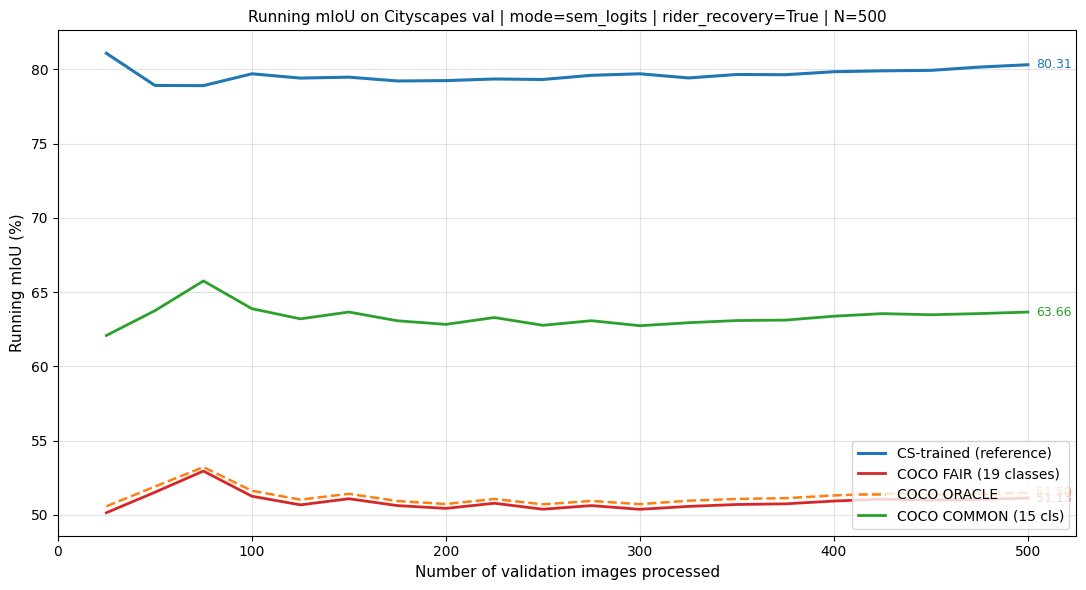


=== Final scores ===
  cs_trained       80.31
  coco_fair        51.13
  coco_oracle      51.50
  coco_common      63.66


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELL 14 — Plot mIoU progression and save figure                         ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ WHEN TO RUN:                                                            ║
# ║   • After Cell 13 (run_evaluation) completes successfully               ║
# ║ WHAT IT DOES:                                                           ║
# ║   • Loads the most recent results JSON from /eval_runs/                 ║
# ║   • Plots running mIoU vs number of images (4 curves)                   ║
# ║   • Saves the figure as PNG next to the JSON                            ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os
import json
import glob
import matplotlib.pyplot as plt

results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
candidates  = sorted(glob.glob(os.path.join(results_dir, "results_*.json")))
assert candidates, f"No results files found in {results_dir}"
latest = candidates[-1]
print(f"Plotting: {latest}")

with open(latest) as f:
    prog_data = json.load(f)

prog = prog_data["miou_progression"]
xs        = [p["n_images"]   for p in prog]
y_cs      = [p["miou_cs"]     for p in prog]
y_fair    = [p["miou_fair"]   for p in prog]
y_oracle  = [p["miou_oracle"] for p in prog]
y_common  = [p["miou_common"] for p in prog]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(xs, y_cs,     label="CS-trained (reference)", linewidth=2.2, color="#1f77b4")
ax.plot(xs, y_fair,   label="COCO FAIR (19 classes)", linewidth=2.0, color="#d62728")
ax.plot(xs, y_oracle, label="COCO ORACLE",            linewidth=1.8, color="#ff7f0e", linestyle="--")
ax.plot(xs, y_common, label="COCO COMMON (15 cls)",   linewidth=2.0, color="#2ca02c")

# Annotate final values
for label, ys, color in [
    ("CS",     y_cs,     "#1f77b4"),
    ("FAIR",   y_fair,   "#d62728"),
    ("ORACLE", y_oracle, "#ff7f0e"),
    ("COMMON", y_common, "#2ca02c"),
]:
    ax.annotate(f"{ys[-1]:.2f}",
                xy=(xs[-1], ys[-1]),
                xytext=(6, 0), textcoords="offset points",
                fontsize=9, color=color, va="center")

ax.set_xlabel("Number of validation images processed", fontsize=11)
ax.set_ylabel("Running mIoU (%)", fontsize=11)

cfg = prog_data["config"]
title = (f"Running mIoU on Cityscapes val | "
         f"mode={cfg['coco_mode']} | rider_recovery={cfg['use_rider_recovery']} | "
         f"N={cfg['n_images_evaluated']}")
ax.set_title(title, fontsize=11)
ax.grid(True, alpha=0.35)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(0, max(xs) * 1.05)
fig.tight_layout()

# Save next to the JSON
png_path = latest.replace("results_", "miou_progression_").replace(".json", ".png")
fig.savefig(png_path, dpi=150, bbox_inches="tight")
print(f"✓ Plot saved: {png_path}")
plt.show()

# Print final scores for quick reference
print("\n=== Final scores ===")
for k, v in prog_data["final_miou"].items():
    print(f"  {k:<15} {v:>6.2f}")

✓ Figure 1 (per-class bars): /content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs/fig1_per_class_sem_logits_rider1_20260526_180449.png


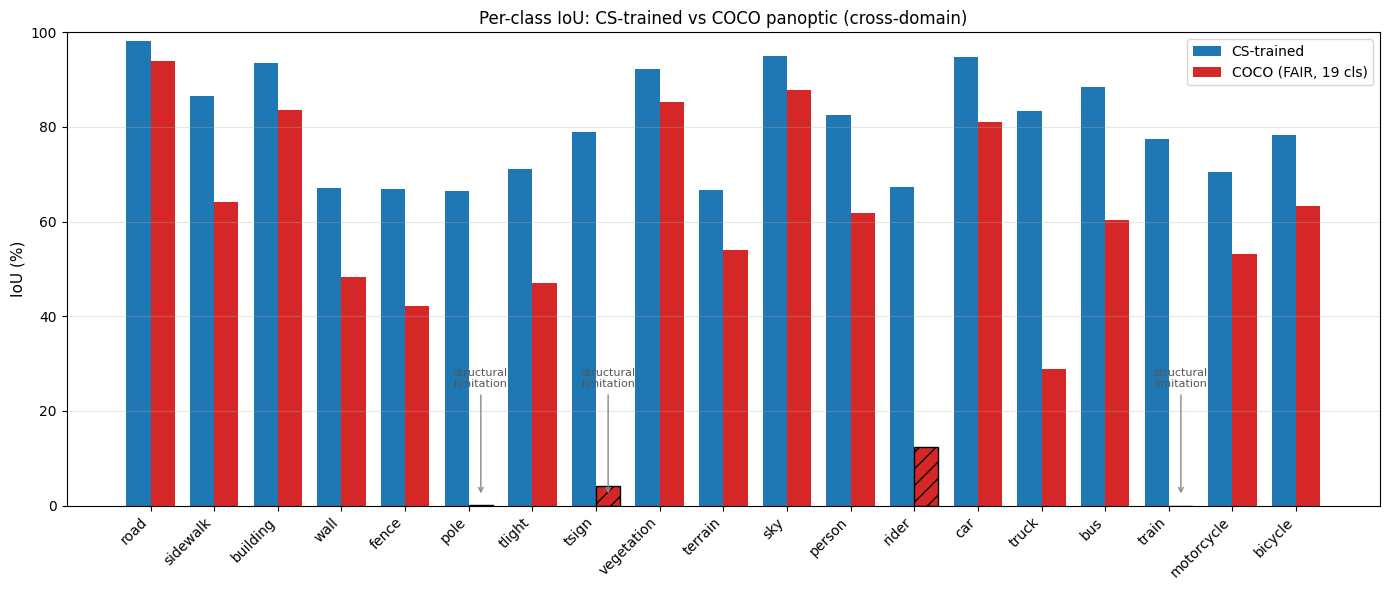

✓ Figure 2 (IoU vs support): /content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs/fig2_iou_vs_support_sem_logits_rider1_20260526_180449.png


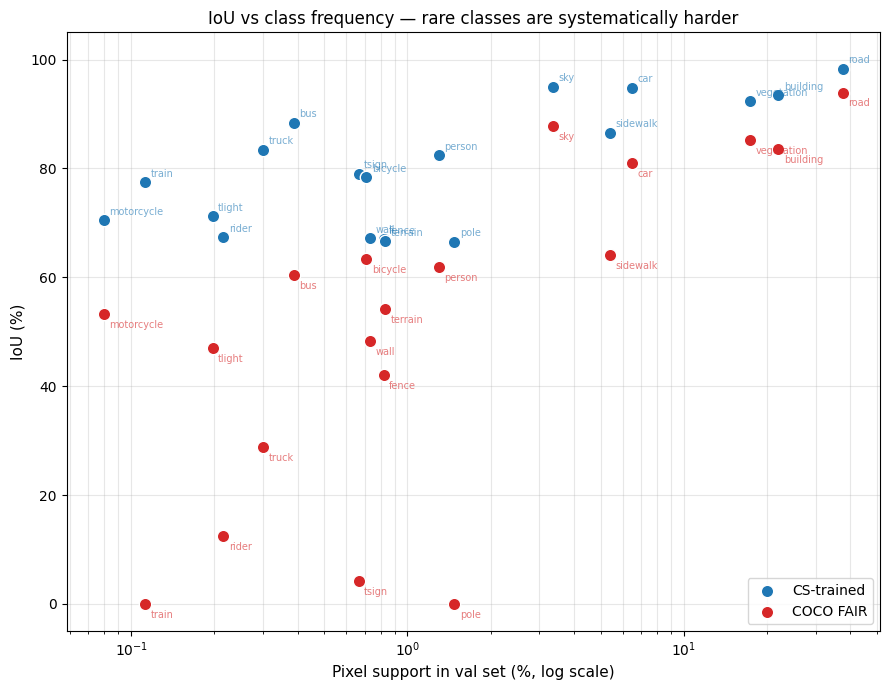

✓ Figure 3 (qualitative): /content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs/fig3_qualitative_sem_logits_rider1_20260526_180449.png


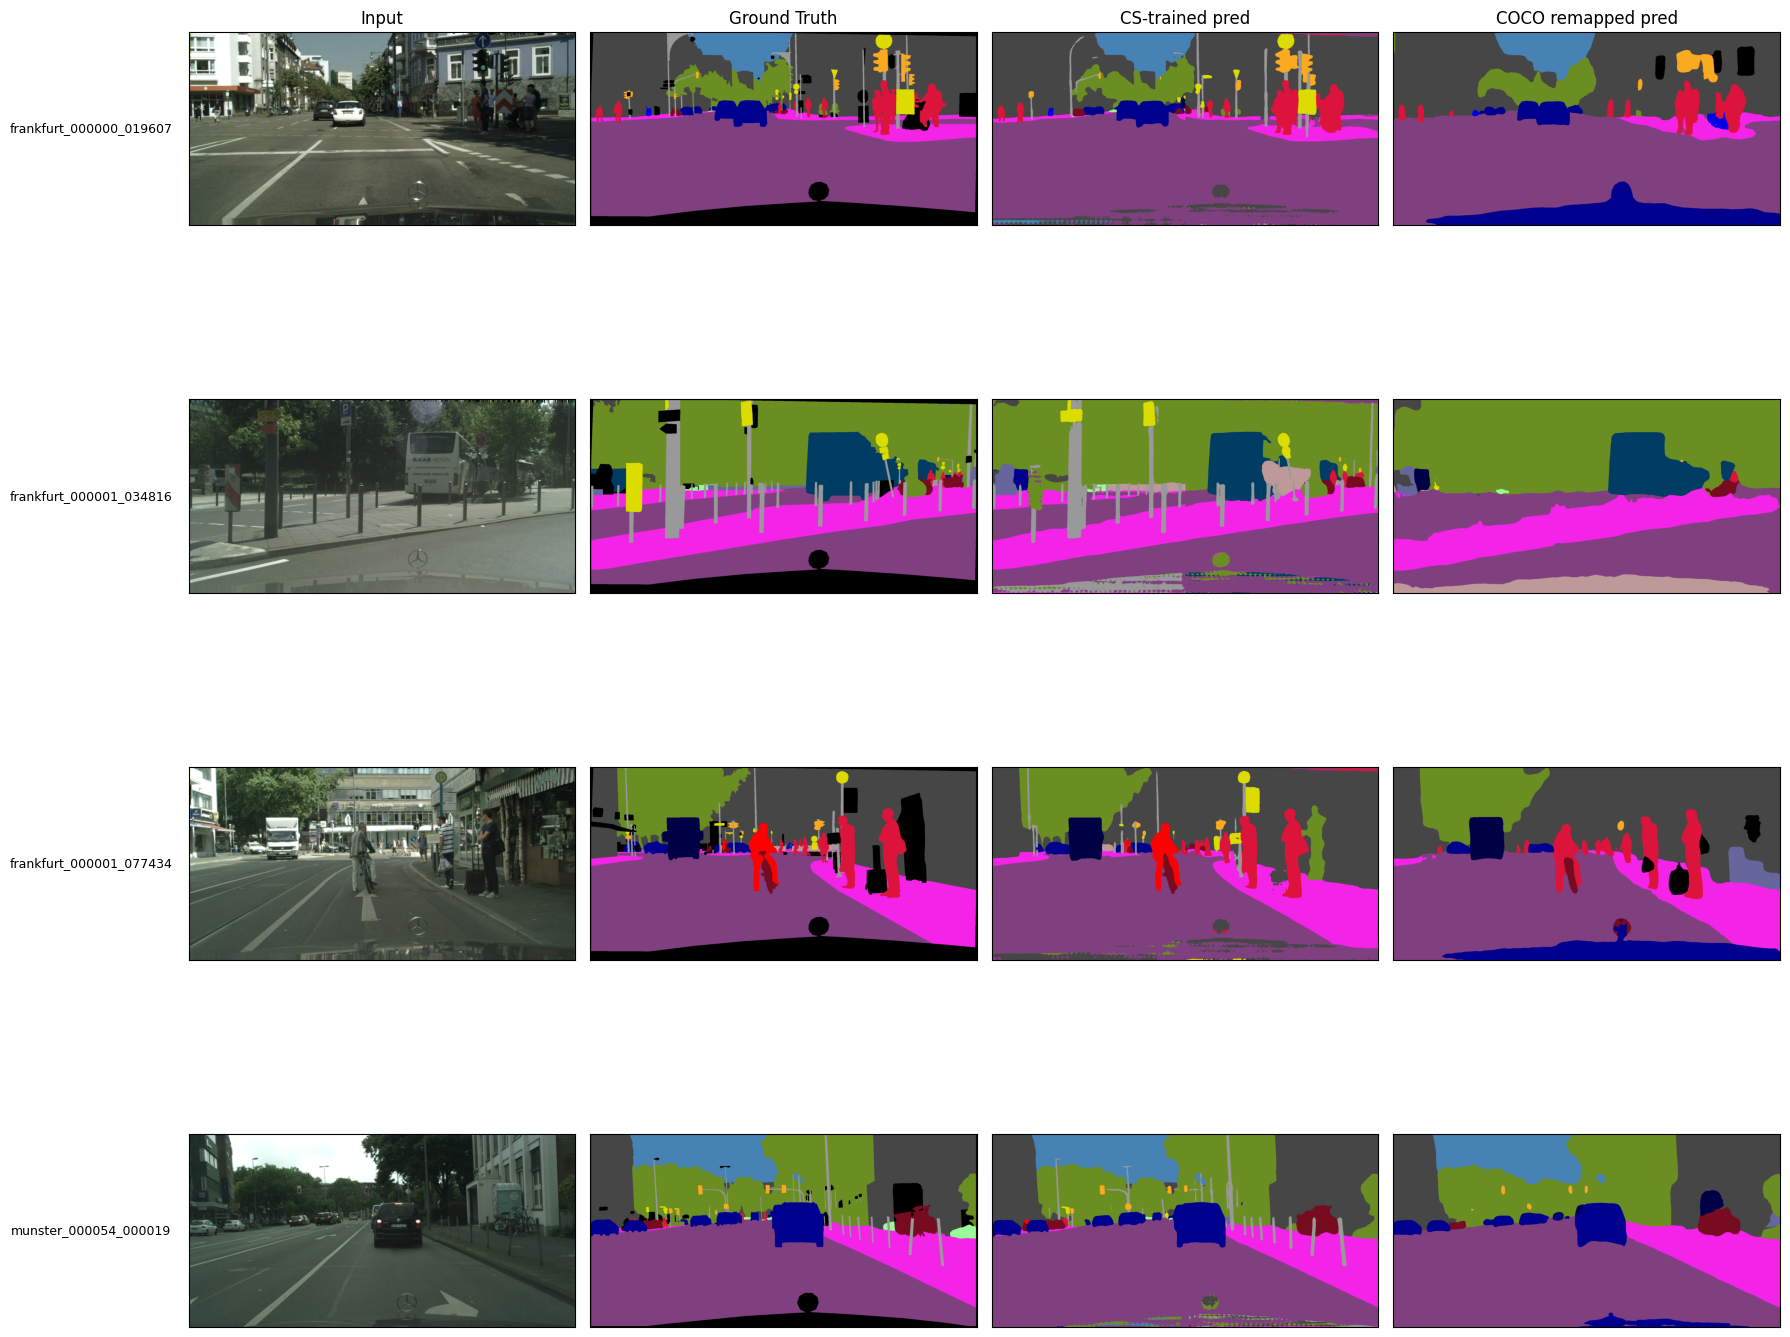


Summary table for the paper (LaTeX-ready)
Class           Support  CS-trained   COCO FAIR  COCO ORACLE  Common
--------------------------------------------------------------------------------
road             37.65%      98.27       93.94        94.07  ✓
sidewalk          5.41%      86.59       64.09        64.12  ✓
building         21.92%      93.47       83.54        85.38  ✓
wall              0.73%      67.18       48.28        48.35  ✓
fence             0.82%      66.95       42.12        43.43  ✓
pole              1.48%      66.52        0.05         0.05  —
tlight            0.20%      71.20       46.95        47.05  ✓
tsign             0.67%      79.03        4.12         4.40  —
vegetation       17.32%      92.35       85.19        85.29  ✓
terrain           0.83%      66.60       54.09        54.16  ✓
sky               3.35%      94.98       87.84        87.86  ✓
person            1.30%      82.45       61.92        64.07  ✓
rider             0.22%      67.39       12.45     

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELL 14b — Publication-ready visualizations for the report              ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ Generates 4 figures from the latest results_*.json:                     ║
# ║   1. Per-class bar chart (CS vs COCO FAIR vs COCO COMMON)               ║
# ║   2. Per-class IoU vs pixel support (scatter, log-log)                  ║
# ║   3. Side-by-side qualitative comparison on 4 validation images         ║
# ║   4. Confusion matrix of COCO predictions (CS taxonomy)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# Locate latest results JSON
results_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project/eval_runs"
candidates = sorted(glob.glob(os.path.join(results_dir, "results_*.json")))
latest = candidates[-1]
with open(latest) as f:
    results = json.load(f)

CS_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "tlight",
    "tsign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]
out_dir = os.path.dirname(latest)
tag = os.path.basename(latest).replace("results_", "").replace(".json", "")

# ─── Figure 1: per-class bar chart ───
fig, ax = plt.subplots(figsize=(14, 6))
cs_iou   = [results["per_class_iou_pct"][c]["cs_trained"] for c in CS_CLASSES]
coco_iou = [results["per_class_iou_pct"][c]["coco_fair"]  for c in CS_CLASSES]
in_common = [results["per_class_iou_pct"][c]["in_common"] for c in CS_CLASSES]

x = np.arange(len(CS_CLASSES))
w = 0.38
b1 = ax.bar(x - w/2, cs_iou,   w, label="CS-trained",        color="#1f77b4")
b2 = ax.bar(x + w/2, coco_iou, w, label="COCO (FAIR, 19 cls)", color="#d62728")

# Mark non-COMMON classes with a hatch
for i, ic in enumerate(in_common):
    if not ic:
        b2[i].set_hatch("//")
        b2[i].set_edgecolor("black")

ax.set_xticks(x)
ax.set_xticklabels(CS_CLASSES, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("IoU (%)", fontsize=11)
ax.set_title("Per-class IoU: CS-trained vs COCO panoptic (cross-domain)", fontsize=12)
ax.set_ylim(0, 100)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper right", fontsize=10)

# Annotate the structural-zero classes
for i, c in enumerate(CS_CLASSES):
    if coco_iou[i] < 5 and not in_common[i]:
        ax.annotate("structural\nlimitation", xy=(i + w/2, 2),
                    xytext=(i + w/2, 25), ha="center", fontsize=8,
                    color="#555", arrowprops=dict(arrowstyle="->", color="#888"))

fig.tight_layout()
fig1_path = os.path.join(out_dir, f"fig1_per_class_{tag}.png")
fig.savefig(fig1_path, dpi=180, bbox_inches="tight")
print(f"✓ Figure 1 (per-class bars): {fig1_path}")
plt.show()

# ─── Figure 2: IoU vs pixel support (scatter) ───
fig, ax = plt.subplots(figsize=(9, 7))
supports = [results["per_class_iou_pct"][c]["pixel_support_pct"] for c in CS_CLASSES]
cs_arr   = np.array(cs_iou)
co_arr   = np.array(coco_iou)
sup_arr  = np.array(supports)

ax.scatter(sup_arr, cs_arr, s=80, color="#1f77b4", label="CS-trained", zorder=3, edgecolor="white")
ax.scatter(sup_arr, co_arr, s=80, color="#d62728", label="COCO FAIR",  zorder=3, edgecolor="white")
for i, name in enumerate(CS_CLASSES):
    ax.annotate(name, (sup_arr[i], cs_arr[i]), xytext=(4, 4),
                textcoords="offset points", fontsize=7, alpha=0.6, color="#1f77b4")
    ax.annotate(name, (sup_arr[i], co_arr[i]), xytext=(4, -10),
                textcoords="offset points", fontsize=7, alpha=0.6, color="#d62728")

ax.set_xscale("log")
ax.set_xlabel("Pixel support in val set (%, log scale)", fontsize=11)
ax.set_ylabel("IoU (%)", fontsize=11)
ax.set_title("IoU vs class frequency — rare classes are systematically harder",
             fontsize=12)
ax.grid(True, alpha=0.3, which="both")
ax.legend(loc="lower right", fontsize=10)
ax.set_ylim(-5, 105)
fig.tight_layout()
fig2_path = os.path.join(out_dir, f"fig2_iou_vs_support_{tag}.png")
fig.savefig(fig2_path, dpi=180, bbox_inches="tight")
print(f"✓ Figure 2 (IoU vs support): {fig2_path}")
plt.show()

# ─── Figure 3: qualitative side-by-side on N images ───
CITYSCAPES_COLORS = np.array([
    [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156], [190, 153, 153],
    [153, 153, 153], [250, 170, 30], [220, 220, 0], [107, 142, 35], [152, 251, 152],
    [70, 130, 180], [220, 20, 60], [255, 0, 0], [0, 0, 142], [0, 0, 70],
    [0, 60, 100], [0, 80, 100], [0, 0, 230], [119, 11, 32]
], dtype=np.uint8)

def colorize_cs(pred):
    """[H, W] in {0..18, 255} -> [H, W, 3] uint8 with Cityscapes palette."""
    rgb = np.zeros((*pred.shape, 3), dtype=np.uint8)
    for c in range(19):
        rgb[pred == c] = CITYSCAPES_COLORS[c]
    rgb[pred == 255] = [0, 0, 0]   # unmappable -> black
    return rgb

# Use _resolve_val_dataset semantics from script
# === Robust resolver: handles DataModule, DataLoader, dict, list, raw Dataset ===
def _resolve_val_dataset(dm):
    if hasattr(dm, "val_dataloader"):
        vl = dm.val_dataloader()
    elif hasattr(dm, "dataset"):
        return dm.dataset
    elif isinstance(dm, dict):
        val_keys = [k for k in dm.keys() if "val" in str(k).lower()]
        vl = dm[val_keys[0]] if val_keys else next(iter(dm.values()))
    elif isinstance(dm, (list, tuple)):
        vl = dm[0]
    else:
        return dm
    if isinstance(vl, dict):
        val_keys = [k for k in vl.keys() if "val" in str(k).lower()]
        vl = vl[val_keys[0]] if val_keys else next(iter(vl.values()))
    elif isinstance(vl, (list, tuple)):
        vl = vl[0]
    if hasattr(vl, "dataset"):
        return vl.dataset
    return vl

val_dataset = _resolve_val_dataset(data)

# Defensive: catch silent failures
if not hasattr(val_dataset, "imgs"):
    raise TypeError(
        f"Resolver returned {type(val_dataset).__name__} which has no .imgs. "
        f"Likely cause: the variable `data` was overwritten somewhere (e.g., "
        f"Cell 13 used `data = json.load(...)`). Re-run Cell 6 to restore the DataModule."
    )

assert hasattr(val_dataset, "imgs"), \
    f"val_dataset is {type(val_dataset)} without .imgs — inspect `data` in the notebook."
sample_indices = [42, 137, 256, 380]  # 4 diverse Cityscapes val images
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(18, 4*len(sample_indices)))
col_titles = ["Input", "Ground Truth", "CS-trained pred", "COCO remapped pred"]

from PIL import Image
for row, idx in enumerate(sample_indices):
    img_path = val_dataset.imgs[idx]
    gt_path  = val_dataset.targets[idx]
    if not img_path.startswith("/"):
        img_path = os.path.join("/content/datasets/cityscapes", img_path)
        gt_path  = os.path.join("/content/datasets/cityscapes", gt_path)

    pil = Image.open(img_path).convert("RGB")
    img_tensor = torch.from_numpy(np.array(pil)).permute(2, 0, 1)

    raw_gt = np.array(Image.open(gt_path))
    from evaluate_quantitative import RAW_TO_TRAIN_ID
    gt = RAW_TO_TRAIN_ID[raw_gt]

    # Predictions
    pred_cs = get_cs_semantic_prediction_multiscale(
        model_cs, img_tensor, scales=(1.0,), use_flip=True
    )
    pred_coco_raw = get_coco_semantic_logits_multiscale(
        model_coco, img_tensor, num_classes=133, scales=(1.0,), use_flip=True
    )
    pred_coco = COCO_TO_CS_MAPPING_V2[np.clip(pred_coco_raw, 0, 255)]

    panels = [np.array(pil), colorize_cs(gt), colorize_cs(pred_cs), colorize_cs(pred_coco)]
    for col, panel in enumerate(panels):
        ax = axes[row, col]
        ax.imshow(panel)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(col_titles[col], fontsize=12)
        if col == 0:
            ax.set_ylabel(os.path.basename(img_path).replace("_leftImg8bit.png", ""),
                          fontsize=9, rotation=0, labelpad=70, va="center")

fig.tight_layout()
fig3_path = os.path.join(out_dir, f"fig3_qualitative_{tag}.png")
fig.savefig(fig3_path, dpi=120, bbox_inches="tight")
print(f"✓ Figure 3 (qualitative): {fig3_path}")
plt.show()

# ─── Figure 4: simple summary table (renderable in LaTeX-like text) ───
print("\n" + "="*80)
print("Summary table for the paper (LaTeX-ready)")
print("="*80)
print(f"{'Class':<12} {'Support':>10} {'CS-trained':>11} {'COCO FAIR':>11} {'COCO ORACLE':>12}  Common")
print("-"*80)
for c, name in enumerate(CS_CLASSES):
    rec = results["per_class_iou_pct"][name]
    flag = "✓" if rec["in_common"] else "—"
    print(f"{name:<12} {rec['pixel_support_pct']:>9.2f}% "
          f"{rec['cs_trained']:>10.2f}  "
          f"{rec['coco_fair']:>10.2f}  "
          f"{rec['coco_oracle']:>11.2f}  {flag}")
print("-"*80)
fm = results["final_miou"]
print(f"{'mIoU (19)':<12} {'':>10}  "
      f"{fm['cs_trained']:>10.2f}  {fm['coco_fair']:>10.2f}  "
      f"{fm['coco_oracle']:>11.2f}")
print(f"{'mIoU COMMON':<12} {'':>10}  {'':>10}  {fm['coco_common']:>10.2f}  "
      f"  (15 classes)")
print("="*80)

print(f"\n✓ All figures saved to {out_dir}/")

In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELL 15 — Backup script + results to Drive (OPTIONAL but recommended)   ║
# ╠══════════════════════════════════════════════════════════════════════════╣
# ║ WHEN TO RUN: at the end of each session                                 ║
# ║ WHAT IT DOES:                                                           ║
# ║   • Copies evaluate_quantitative.py to the persistent Drive folder      ║
# ║   • Lists all evaluation runs available under /eval_runs/               ║
# ║   • Verifies that the latest run is fully saved (JSON + CSV + PNG)      ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, glob

backup_dir = "/content/drive/MyDrive/Polito_FAIMLDL_project"
runs_dir   = os.path.join(backup_dir, "eval_runs")
os.makedirs(runs_dir, exist_ok=True)

# 1. Script backup
!cp /content/MaskArchitectureAnomaly_CourseProject/eomt/evaluate_quantitative.py {backup_dir}/

# 2. List all evaluation runs
print("\n=== Evaluation runs saved on Drive ===")
json_files = sorted(glob.glob(os.path.join(runs_dir, "results_*.json")))
if not json_files:
    print("(no runs found — make sure Cell 13 completed and Cell 11 includes the JSON dump)")
else:
    for jf in json_files:
        tag = os.path.basename(jf).replace("results_", "").replace(".json", "")
        csv_ok = os.path.exists(os.path.join(runs_dir, f"per_class_iou_{tag}.csv"))
        png_ok = os.path.exists(os.path.join(runs_dir, f"miou_progression_{tag}.png"))
        size_kb = os.path.getsize(jf) / 1024
        print(f"  • {tag}")
        print(f"      JSON: ✓ ({size_kb:.1f} KB)   "
              f"CSV: {'✓' if csv_ok else '✗'}   "
              f"PNG: {'✓' if png_ok else '✗'}")


=== Evaluation runs saved on Drive ===
  • sem_logits_rider1_20260526_180449
      JSON: ✓ (8.8 KB)   CSV: ✓   PNG: ✓
